# SEGWO Response Analysis — Publication-Ready Figures

This notebook generates all figures for the paper from pre-computed results stored in `./data`.
No heavy computation is performed here; every cell only loads arrays and produces plots.

In [1]:
import os
os.environ["PATH"] = '/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/opt/miniconda3/envs/lisa_resp/bin:/opt/miniconda3/condabin:/usr/local/bin:/System/Cryptexes/App/usr/bin:/usr/bin:/bin:/usr/sbin:/sbin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/local/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/bin:/var/run/com.apple.security.cryptexd/codex.system/bootstrap/usr/appleinternal/bin:/opt/pmk/env/global/bin:/Library/Apple/usr/bin:/Library/TeX/texbin:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/debugCommand:/Users/lorenzo.speri/Library/Application Support/Code/User/globalStorage/github.copilot-chat/copilotCli:/Users/lorenzo.speri/.vscode/extensions/ms-python.debugpy-2026.6.0-darwin-arm64/bundled/scripts/noConfigScripts'

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import healpy as hp
from matplotlib.colors import LogNorm
from lisaconstants.indexing import LINKS
from lisaconstants import C
from plot_utils import plot_orbit_3d
from lisaorbits import StaticConstellation
import corner
from eryn.backends import HDFBackend


plt.rcParams.update()
# ── Publication-quality matplotlib settings ─────────────────────────────────
plt.rcParams.update({
    'text.usetex':       True,        # set True if a LaTeX install is available
    'font.family':       'times',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.frameon':    True,
    'legend.framealpha': 0.8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    ':',
    'lines.linewidth':   1.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── Figure width constants (inches) ─────────────────────────────────────────
COL1 = 3.5   # single-column
COL2 = 7.2   # double-column

# ── Polarisation labels ──────────────────────────────────────────────────────
POLS = (r'$h_+$', r'$h_\times$')

# ── Output directory for paper-quality PDFs ──────────────────────────────────
PAPER_DIR = "paper_plots"
os.makedirs(PAPER_DIR, exist_ok=True)


/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3D orbit plot saved to paper_plots/lisa_orbit_.png
3D orbit plot saved to paper_plots/toy_orbit_.png


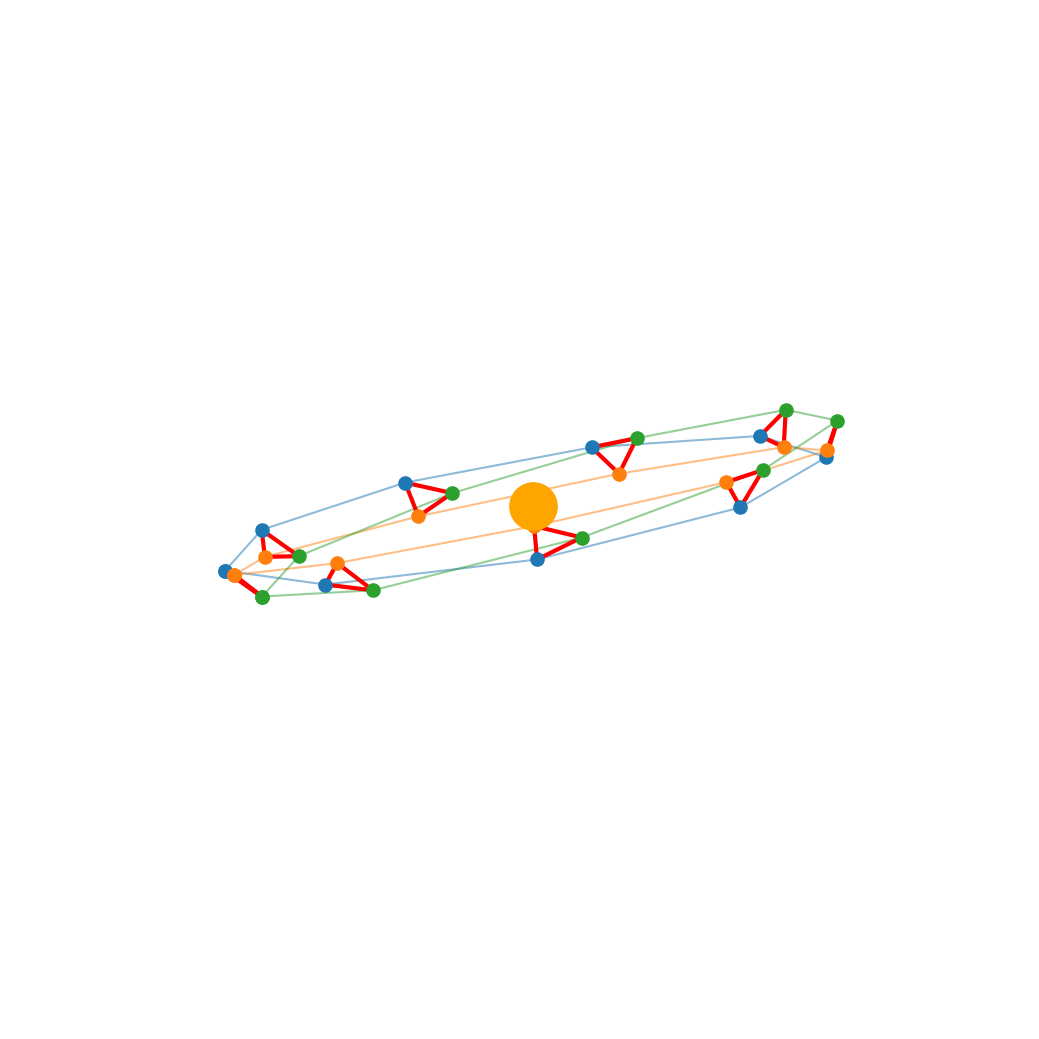

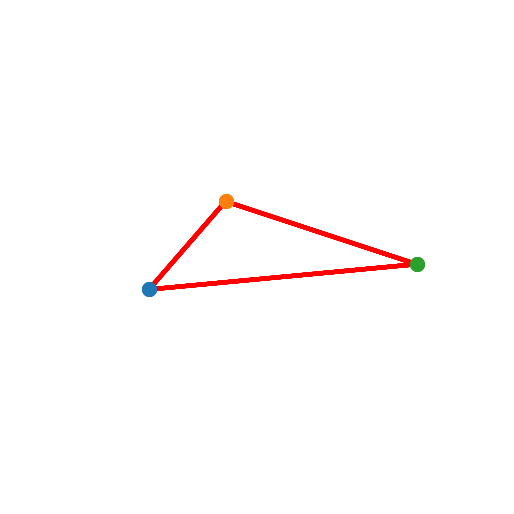

In [3]:
with h5py.File("data/processed_trajectories.h5", "r") as dset:
    t_orb_dataset = dset["t_interp"][()]
    x_orb_dataset = dset["spacecraft_positions"][()]
    v_orb_dataset = dset["spacecraft_velocities"][()]
    ltts_dataset = dset['owlt_12_23_31_13_32_21'][()]

    t_orb = t_orb_dataset
    x_orb = np.median(x_orb_dataset, axis=0)  # Use the median over all realizations
    v_orb = np.median(v_orb_dataset, axis=0)  # Use the median over all realizations
    ltts_median = np.median(ltts_dataset, axis=0)  # Use the median over all realizations
    orbital_info = {"t": t_orb, "x": x_orb, "v": v_orb, "ltt": ltts_median}

plot_orbit_3d(orbital_info, 1.0, output_file=os.path.join(PAPER_DIR, "lisa_orbit_.png"), figsize=(6*2, 2*3.5), include_sun=True)

orbits = StaticConstellation.from_armlengths(2.5e9, 2.5e9, 2.5e9)
orbital_info = {"t": t_orb, "x": orbits.compute_position(t_orb)}
plot_orbit_3d(orbital_info, 1.0, output_file=os.path.join(PAPER_DIR, "toy_orbit_.png"), figsize=(6, 3.5), include_sun=False)

In [5]:
# ── Case definitions ─────────────────────────────────────────────────────────
# Each entry:  human-readable label  →  path to the results directory
CASES = {
    "Arm-length (no boost)":          "segwo_results/static/arm1_rot0.0_trans0.0_boost0.0/",
    "Arm-length (boost)":             "segwo_results/static/arm1_rot0.0_trans0.0_boost1.0/",
    "Rotation (no boost)":     "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost0.0/",
    "Rotation (boost)":        "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost1.0/",
    "Translation (no boost)":  "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost0.0/",
    "Translation (boost)":     "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost1.0/",
    "Realistic (no boost)": "segwo_results/30.0days_evolving_boost0.0/",
    "Realistic (boost)":    "segwo_results/30.0days_evolving_boost1.0/",
    "Toy like realistic (boost)": "segwo_results/static/arm0.3_rot150.0_trans10000.0_boost1.0/",
}

# Reference case for the perturbation-distribution histograms
REFERENCE_CASE = "Arm-length (boost)"

In [6]:
# ── Data loading ──────────────────────────────────────────────────────────────
print("✓ Loading full results from segwo_results/")

✓ Loading full results from segwo_results/


In [14]:
def load_results(results_dir):
    """Load all relevant arrays from a results.h5 file."""
    hdf5_path = os.path.join(results_dir, "results.h5")
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"Missing: {hdf5_path}")
    with h5py.File(hdf5_path, "r") as hf:
        data = {
            "f":                     hf["metadata/frequencies"][()],
            "npix":                  int(hf["metadata"].attrs["npix"]),
            "nside":                 int(hf["metadata"].attrs["nside"]),
            "run_flag":              str(hf["metadata"].attrs["run_flag"]),
            "mismatch":              hf["errors/mismatch"][()],
            "strain2x_abs_error":    hf["errors/strain2x_abs_error"][()],
            "strain2x_angle_error":  hf["errors/strain2x_angle_error"][()],
            "strain2x_avg_rel_amp_error": hf["errors/strain2x_avg_rel_amp_error"][()],
        }
        # Optional datasets (not present in all files)
        for key, path in [
            ("angle",             "errors/angle"),
            ("ltt_residuals",     "perturbed/ltt_residuals"),
            ("position_residuals","perturbed/position_residuals"),
            ("mismatch_boost",    "nominal/mismatch_boost"),
            ("yaw_difference",   "errors/yaw_difference"),
            ("tilt_difference",  "errors/tilt_difference"),
            ("roll_difference",  "errors/roll_difference"),
        ]:
            if path in hf:
                data[key] = hf[path][()]
    return data

all_data = {}
for label, path in CASES.items():
    try:
        all_data[label] = load_results(path)
        d = all_data[label]
    except FileNotFoundError as e:
        print(f"✗  {label:28s}  {e}")

# Common frequency axis
if all_data:
    f = next(iter(all_data.values()))["f"]
    print(f"\nFrequency range: {f.min():.2e} – {f.max():.2e} Hz  ({f.size} points)")


Frequency range: 1.00e-04 – 1.00e+00 Hz  (150 points)


In [15]:

from cycler import cycler
# ── Publication-quality matplotlib settings ─────────────────────────────────
# Wong 2011 colorblind-friendly palette (8 colors)
# WONG_COLORS = [
#     '#000000',  # black
#     '#E69F00',  # orange
#     '#56B4E9',  # sky blue
#     '#009E73',  # bluish green
#     '#F0E442',  # yellow
#     '#0072B2',  # blue
#     '#D55E00',  # vermillion
#     '#CC79A7',  # reddish purple
# ]

COLORBLIND_PALETTE = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7"   # reddish purple
]

plt.rcParams.update({
    'text.usetex':       True,        # set True if a LaTeX install is available
    'font.family':       'times',
    'font.size':         9,
    'axes.labelsize':    9,
    'axes.titlesize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'legend.frameon':    True,
    'legend.framealpha': 0.8,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    ':',
    'lines.linewidth':   1.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.prop_cycle':   cycler('color', COLORBLIND_PALETTE),
})

## Orbital Perturbation Distributions

Histograms of the light-travel-time (LTT) residuals, spacecraft position residuals,
and orbit normal-vector angle offsets drawn from the Monte Carlo sample for the reference case.

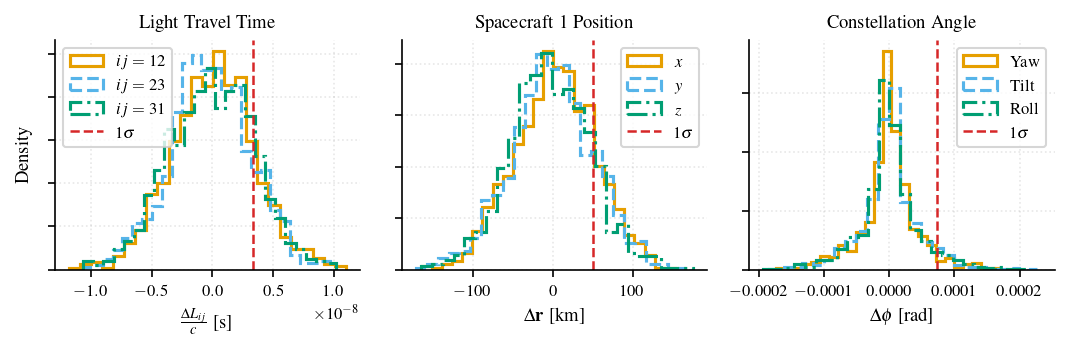

In [16]:
# "Arm (no boost)":          "segwo_results/static/arm1_rot0.0_trans0.0_boost0.0/",
# "Arm (boost)":             "segwo_results/static/arm1_rot0.0_trans0.0_boost1.0/",
# "Rotation (no boost)":     "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost0.0/",
# "Rotation (boost)":        "segwo_results/static/arm0.0_rot50000.0_trans0.0_boost1.0/",
# "Translation (no boost)":  "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost0.0/",
# "Translation (boost)":     "segwo_results/static/arm0.0_rot0.0_trans50000.0_boost1.0/",

ref = all_data["Arm-length (boost)"]
linestyle = ['-', '--', '-.']

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))

# ── LTT residuals ───────────────────────────────────────────────────────────
ref = all_data["Arm-length (boost)"]
ax = axes[0]
for i in range(3):
    ax.hist(
        ref["ltt_residuals"][:, i], bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        # label=rf"$\Delta L_{{{LINKS[i]}}}$",
        label=rf"$ij = {{{LINKS[i]}}}$",
    )
ax.set_xlabel(r"$\frac{\Delta L_{ij}}{c}$ [s]")
ax.set_ylabel("Density")
ax.axvline(1.0/C, color='tab:red', ls='--', lw=1.2, label=r"$1\sigma$")
ax.set_yticklabels([])
ax.set_title("Light Travel Time")
ax.legend()
std_ltt = np.std(ref["ltt_residuals"], axis=0)

# ── Position residuals (SC 1) ────────────────────────────────────────────────
ref = all_data["Translation (boost)"]

ax = axes[1]
for i, lbl in enumerate(["$x$", "$y$", "$z$"]):
    ax.hist(
        ref["position_residuals"][:, 0, i] / 1e3, bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        label=lbl,
    )
ax.set_xlabel(r"$\Delta \mathbf{r}$ [km]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.axvline(50.0, color='tab:red', ls='--', lw=1.2, label=r"$1\sigma$")
ax.set_title("Spacecraft 1 Position")
ax.legend()
std_pos = np.std(ref["position_residuals"][:, 0, :], axis=0) / 1e3

# ── Orbit tilt angle ─────────────────────────────────────────────────────────
ref = all_data["Rotation (boost)"]
ax = axes[2]
dist_centroid = 2.5e9 * np.sqrt(1 / 3)
rot_fac = 2.127
expected_sigma = 50e3 * rot_fac / dist_centroid
# ax.hist(ref["angle"], bins=25, histtype='step', linewidth=1.5, density=True)
ax.hist(ref["yaw_difference"], bins=25, histtype='step', linewidth=1.5, density=True, label="Yaw")
ax.hist(ref["tilt_difference"], bins=25, histtype='step', linewidth=1.5, density=True, label="Tilt", linestyle='--')
mask_off = ref["roll_difference"] < -5
roll_diff = ref["roll_difference"].copy()
roll_diff[mask_off] = roll_diff[mask_off] + np.pi * 2
ax.hist(roll_diff, bins=25, histtype='step', linewidth=1.5, density=True, label="Roll", linestyle='-.')
ax.axvline(expected_sigma, color='tab:red', ls='--', lw=1.2, label=r"$1\sigma$")
ax.set_xlabel(r"$\Delta\phi$ [rad]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Constellation Angle")
ax.legend()
std_angle = np.std(ref["angle"], axis=0)
std_yaw = np.std(ref["yaw_difference"], axis=0)
std_tilt = np.std(ref["tilt_difference"], axis=0)
std_roll = np.std(roll_diff, axis=0)

plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "static_orbit_perturbation_distributions.png"), dpi=300)
plt.show()


In [18]:
ref.keys()

dict_keys(['f', 'npix', 'nside', 'run_flag', 'mismatch', 'strain2x_abs_error', 'strain2x_angle_error', 'strain2x_avg_rel_amp_error', 'angle', 'ltt_residuals', 'position_residuals', 'mismatch_boost', 'yaw_difference', 'tilt_difference', 'roll_difference'])

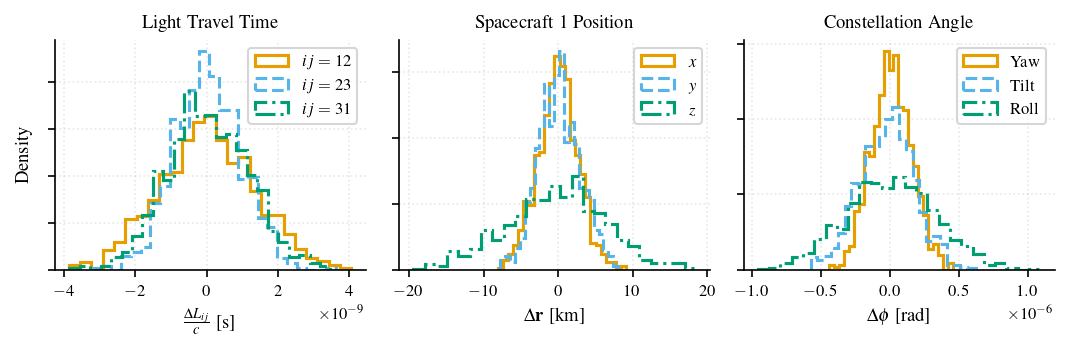

In [19]:
ref = all_data["Realistic (boost)"]
linestyle = ['-', '--', '-.']

fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.4))

# ── LTT residuals ───────────────────────────────────────────────────────────
ax = axes[0]
for i in range(3):
    ax.hist(
        ref["ltt_residuals"][:, i], bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        # label=rf"$\Delta L_{{{LINKS[i]}}}$",
        label=rf"$ij = {{{LINKS[i]}}}$",
    )
ax.set_xlabel(r"$\frac{\Delta L_{ij}}{c}$ [s]")
ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Light Travel Time")
ax.legend()
std_ltt_real = np.std(ref["ltt_residuals"], axis=0)

# ── Position residuals (SC 1) ────────────────────────────────────────────────
ax = axes[1]
for i, lbl in enumerate(["$x$", "$y$", "$z$"]):
    ax.hist(
        ref["position_residuals"][:, 0, i] / 1e3, bins=25,
        histtype='step', linestyle=linestyle[i], linewidth=1.5, density=True,
        label=lbl,
    )
ax.set_xlabel(r"$\Delta \mathbf{r}$ [km]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Spacecraft 1 Position")
ax.legend()
std_pos_real = np.std(ref["position_residuals"][:, 0, :], axis=0) / 1e3

# ── Orbit tilt angle ─────────────────────────────────────────────────────────
ax = axes[2]
dist_centroid = 2.5e9 * np.sqrt(1 / 3)
expected_sigma = 50e3 * 2.13 / dist_centroid
# ax.hist(ref["angle"], bins=25, histtype='step', linewidth=1.5, density=True)
ax.hist(ref["yaw_difference"], bins=25, histtype='step', linewidth=1.5, density=True, label="Yaw")
ax.hist(ref["tilt_difference"], bins=25, histtype='step', linewidth=1.5, density=True, label="Tilt", linestyle='--')
mask_off = ref["roll_difference"] < -5
roll_diff = ref["roll_difference"].copy()
roll_diff[mask_off] = roll_diff[mask_off] + np.pi * 2
ax.hist(roll_diff, bins=25, histtype='step', linewidth=1.5, density=True, label="Roll", linestyle='-.')
ax.set_xlabel(r"$\Delta\phi$ [rad]")
# ax.set_ylabel("Density")
ax.set_yticklabels([])
ax.set_title("Constellation Angle")
ax.legend()
std_angle_real = np.std(ref["angle"], axis=0)
std_tilt_real = np.std(ref["tilt_difference"], axis=0)
std_roll_real = np.std(roll_diff, axis=0)
std_yaw_real = np.std(ref["yaw_difference"], axis=0)

# fig.suptitle(f"Reference case: {REFERENCE_CASE}", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "evolving_orbit_perturbation_distributions.png"), dpi=300)
plt.show()


In [20]:
# print std values for toy and realistic cases
print("Toy orbit (Arm-length boost):")
print(f"  LTT std:   {std_ltt} s")
print(f"  Position std: {std_pos} km")
print(f"  Angle std: {std_angle} rad")

print("\nRealistic orbit (Arm-length boost):")
print(f"  LTT std:   {std_ltt_real} s", std_ltt_real*C, "m")
print(f"  Position std: {std_pos_real} km")
print(f"  Angle std: {std_angle_real} rad")
# print ratios  
print("=" * 40)
print("\nRatios (Toy/Realistic):")
print(f"  LTT std ratio:   {std_ltt / std_ltt_real}")
print(f"  Position std ratio: {std_pos / std_pos_real}")
# print(f"  Angle std ratio: {std_angle / std_angle_real}")
print(f"\n  Angle std ratio: {std_angle / std_angle_real}")  # --- IGNORE ---
print(f"  Yaw std ratio: {std_yaw / std_angle_real}")
print(f"  Tilt std ratio: {std_tilt / std_angle_real}")
print(f"  Roll std ratio: {std_roll / std_angle_real}")


Toy orbit (Arm-length boost):
  LTT std:   [3.41492763e-09 3.29812063e-09 3.47671090e-09 3.47671090e-09
 3.29812063e-09 3.41492763e-09] s
  Position std: [50.13983051 51.78228742 50.29050993] km
  Angle std: 4.136819726645036e-05 rad

Realistic orbit (Arm-length boost):
  LTT std:   [1.33168296e-09 9.30542115e-10 1.12860720e-09 1.12882890e-09
 9.29472670e-10 1.32585611e-09] s [0.39922851 0.27896951 0.33834793 0.33841439 0.2786489  0.39748166] m
  Position std: [2.70041757 2.84405982 6.59944293] km
  Angle std: 1.5588433918930298e-07 rad

Ratios (Toy/Realistic):
  LTT std ratio:   [2.56436986 3.54430023 3.08053226 3.07992726 3.54837827 2.57563969]
  Position std ratio: [18.56743603 18.20717238  7.62041743]

  Angle std ratio: 265.3775066924049
  Yaw std ratio: 279.9744546959205
  Tilt std ratio: 285.42476450436504
  Roll std ratio: 291.15252934276685


# Link Response

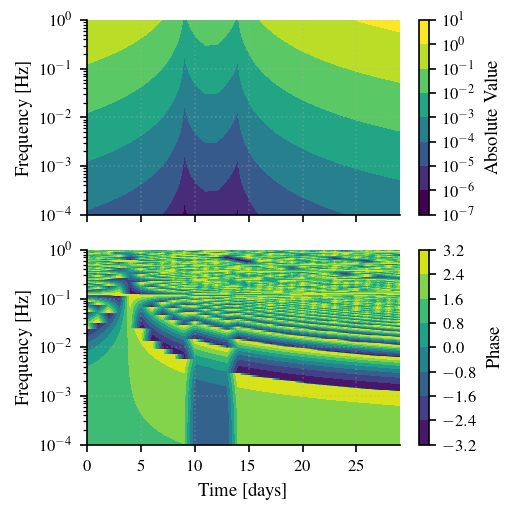

In [45]:
import matplotlib.colors as mcolors

with h5py.File("data/link_response_maps.h5", "r") as ds:
    f_ = ds["frequencies"][()]
    amp_map = ds["amp_map"][()]
    phase_map = ds["phase_map"][()]
    array_ltts = ds["array_ltts"][()]
    

fig, axes = plt.subplots(2, 1, figsize=(COL1, COL1), sharex=True)

positive_vals = amp_map[amp_map > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts / 86400,
    f_,
    amp_map,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].axhline(1 / (np.pi * 8.2), color='r')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts / 86400, f_, phase_map)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
# axes[1].axhline(1 / (np.pi * 8.2), color='r')
axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig("paper_plots/link_response_evolution.png", dpi=300)

## Response Evolution

In [89]:
with h5py.File("data/response_evolution_plot.h5", "r") as ds:
    array_ltts_ = ds["array_ltts"][:]
    f_ = ds["frequencies"][:]
    phase_map_ = ds["phase_map"][:]
    amp_map_ = ds["amp_map"][:]
    phase_map_pert_ = ds["phase_map_pert"][:]
    amp_map_pert_ = ds["amp_map_pert"][:]
    ltts_ = ds["ltts"][:]

array_ltts_.shape, f_.shape, phase_map_.shape, amp_map_.shape,ltts_.shape

((240,), (299,), (299, 240), (299, 240), (240, 6))

In [90]:
f_ltt = 1 / ltts_[:,0]

<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_58341/1518357845.py:29: SyntaxWarning: invalid escape sequence '\m'
  axes[0].legend(loc='upper right', fontsize=10, ncol=2, title="$f_{\mathrm{zero}} = 1 / \mathrm{LTT}$", title_fontsize=10, bbox_to_anchor=(1.0, 1.3))


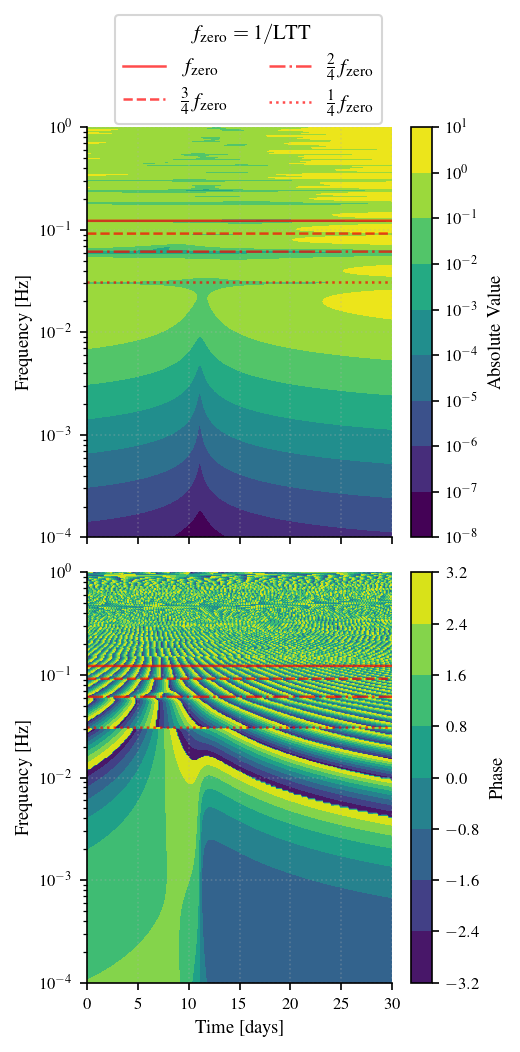

In [95]:
fig, axes = plt.subplots(2, 1, figsize=(COL1, COL1*2), sharex=True)

positive_vals = amp_map_[amp_map_ > 0]
vmin = positive_vals.min()

cf1 = axes[0].contourf(
    array_ltts_ / 86400,
    f_,
    amp_map_,
    levels=5,
    norm=mcolors.LogNorm(vmin=vmin, vmax=amp_map_.max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts_ / 86400, f_, phase_map_)#, cmap=mymap)
fig.colorbar(cf2, ax=axes[1], label='Phase')
for k in range(2):
    axes[k].plot(array_ltts_ / 86400, f_ltt, color='r', ls='-', lw=1.2, label=r"$f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, 3*f_ltt/4, color='r', ls='--', lw=1.2, label=r"$\frac{3}{4} f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, 2*f_ltt/4, color='r', ls='-.', lw=1.2, label=r"$\frac{2}{4} f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, f_ltt/4, color='r', ls=':', lw=1.2, label=r"$\frac{1}{4} f_{\mathrm{zero}}$", alpha=0.7)

axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')
axes[0].legend(loc='upper right', fontsize=10, ncol=2, title="$f_{\mathrm{zero}} = 1 / \mathrm{LTT}$", title_fontsize=10, bbox_to_anchor=(1.0, 1.3))

plt.tight_layout()
plt.savefig("paper_plots/response_evolution.png", dpi=300)

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_58341/3589178176.py:26: SyntaxWarning: invalid escape sequence '\m'
  axes[0].legend(loc='upper right', fontsize=10, ncol=2, title="$f_{\mathrm{zero}} = 1 / \mathrm{LTT}$", title_fontsize=10, bbox_to_anchor=(1.0, 1.3))


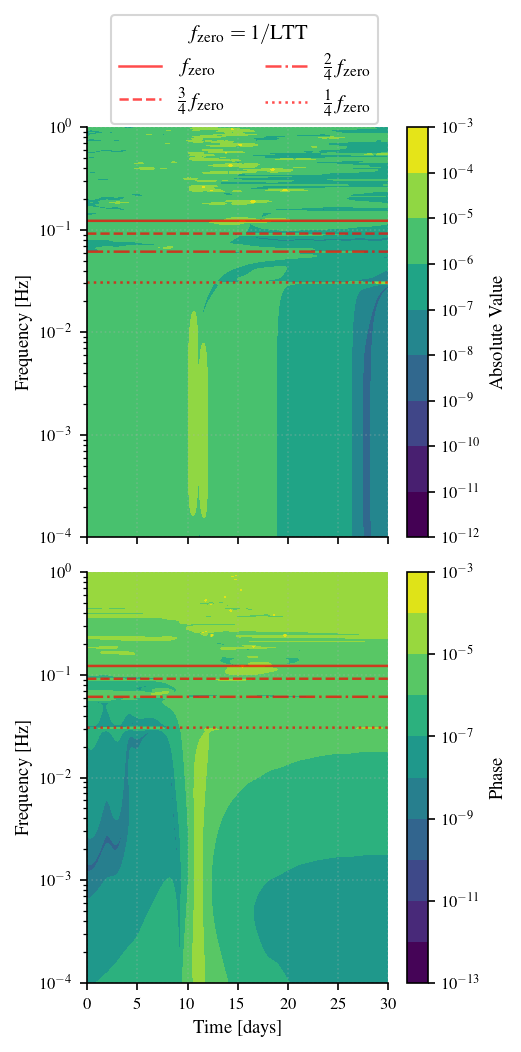

In [97]:
fig, axes = plt.subplots(2, 1, figsize=(COL1, COL1*2), sharex=True)

cf1 = axes[0].contourf(
    array_ltts_ / 86400,
    f_,
    np.abs(1 - amp_map_ / amp_map_pert_),
    levels=5,
    norm=mcolors.LogNorm(vmin=np.abs(1 - amp_map_ / amp_map_pert_).min(), vmax=np.abs(1 - amp_map_ / amp_map_pert_).max())
)
fig.colorbar(cf1, ax=axes[0], label='Absolute Value')
# axes[0].set_ylim(1e-2, 1)
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_yscale('log')

cf2 = axes[1].contourf(array_ltts_ / 86400, f_, np.abs(phase_map_ - phase_map_pert_), levels=5, norm=mcolors.LogNorm(vmin=np.abs(phase_map_ - phase_map_pert_).min(), vmax=np.abs(phase_map_ - phase_map_pert_).max()))
fig.colorbar(cf2, ax=axes[1], label='Phase')
for k in range(2):
    axes[k].plot(array_ltts_ / 86400, f_ltt, color='r', ls='-', lw=1.2, label=r"$f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, 3*f_ltt/4, color='r', ls='--', lw=1.2, label=r"$\frac{3}{4} f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, 2*f_ltt/4, color='r', ls='-.', lw=1.2, label=r"$\frac{2}{4} f_{\mathrm{zero}}$", alpha=0.7)
    axes[k].plot(array_ltts_ / 86400, f_ltt/4, color='r', ls=':', lw=1.2, label=r"$\frac{1}{4} f_{\mathrm{zero}}$", alpha=0.7)

axes[1].set_xlabel('Time [days]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_yscale('log')
axes[0].legend(loc='upper right', fontsize=10, ncol=2, title="$f_{\mathrm{zero}} = 1 / \mathrm{LTT}$", title_fontsize=10, bbox_to_anchor=(1.0, 1.3))

plt.tight_layout()
# plt.savefig("paper_plots/response_evolution.png", dpi=300)

## Amplitude and Phase errors

In [16]:
all_data.keys()
data = all_data["Realistic (no boost)"]
print("Realistic (no boost) strain2x_abs_error shape:", data["strain2x_abs_error"].shape)
data = all_data["Realistic (boost)"]
print("Realistic (boost) strain2x_abs_error shape:", data["strain2x_abs_error"].shape)

Realistic (no boost) strain2x_abs_error shape: (150, 432, 3, 2)
Realistic (boost) strain2x_abs_error shape: (150, 432, 3, 2)


Realistic (no boost):
  Amplitude error at 1e-04 Hz: 9.60e-03
  Phase error at 1e-04 Hz: 5.79e-02
  Amplitude error at 1e-03 Hz: 2.07e-03
  Phase error at 1e-03 Hz: 1.27e-02
  Amplitude error at 1e-02 Hz: 1.91e-04
  Phase error at 1e-02 Hz: 3.54e-04
  Amplitude error at 1e+00 Hz: 1.14e-04
  Phase error at 1e+00 Hz: 3.36e-04
Realistic (boost):
  Amplitude error at 1e-04 Hz: 3.30e-06
  Phase error at 1e-04 Hz: 1.03e-06
  Amplitude error at 1e-03 Hz: 3.92e-06
  Phase error at 1e-03 Hz: 1.04e-06
  Amplitude error at 1e-02 Hz: 2.16e-06
  Phase error at 1e-02 Hz: 3.29e-06
  Amplitude error at 1e+00 Hz: 9.82e-06
  Phase error at 1e+00 Hz: 2.73e-04


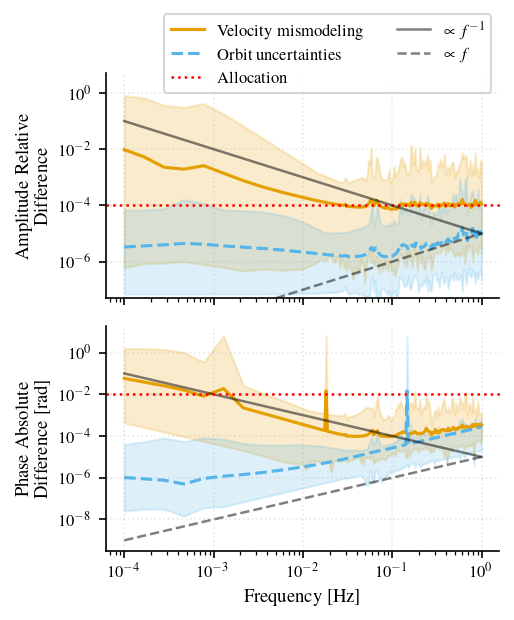

In [106]:
pols=('$h_+$', r'$h_\times$')

fig, axs = plt.subplots(2, 1, figsize=(COL1, 1.2*COL1), sharex=True)

ch = 0 # which TDI channel
pol = 0
labels = ['Velocity mismodeling', 'Orbit uncertainties']
linestyle = ['-', '--']

for i, name in enumerate(['Realistic (no boost)', 'Realistic (boost)']):
    data = all_data[name]
    
    # Full results: (F, N_real, 3, 2) - compute means and min/max
    amp_err = data["strain2x_abs_error"]  # (F, N_real, 3, 2)
    freq_mean_abs = np.mean(amp_err, axis=1)[:, ch, pol]
    freq_min = np.min(amp_err, axis=1)[:, ch, pol]
    freq_max = np.max(amp_err, axis=1)[:, ch, pol]
    
    axs[0].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[0].loglog(f, freq_mean_abs, label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    
    # Phase errors
    angle_err = data["strain2x_angle_error"]  # (F, N_real, 3, 2)
    freq_mean_angle = np.mean(angle_err, axis=1)[:, ch, pol]
    freq_min = np.min(angle_err, axis=1)[:, ch, pol]
    freq_max = np.max(angle_err, axis=1)[:, ch, pol]
    
    axs[1].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[1].loglog(f, freq_mean_angle, label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    
    # Summary statistics
    print(f"{name}:")
    test_f = np.asarray([1e-4, 1e-3, 1e-2, 1])
    for tf in test_f:
        print(f"  Amplitude error at {tf:.0e} Hz: {np.interp(tf, f, freq_mean_abs):.2e}")
        print(f"  Phase error at {tf:.0e} Hz: {np.interp(tf, f, freq_mean_angle):.2e}")

axs[0].axhline(1e-4, color='r', ls=':', lw=1.2, label="Allocation")
axs[0].set_ylabel("Amplitude Relative \nDifference")
axs[0].loglog(f, 1e-5/f, color='k', ls=linestyle[0], lw=1.2, label=r"$\propto f^{-1}$", alpha=0.5)
axs[0].loglog(f, 1e-5*f, color='k', ls=linestyle[1], lw=1.2, label=r"$\propto f$", alpha=0.5)
axs[0].legend(ncol=2, title_fontsize=10, bbox_to_anchor=(1., 1.3))
axs[1].loglog(f, 1e-5/f, color='k', ls=linestyle[0], lw=1.2, label=r"$\propto f^{-1}$", alpha=0.5)
axs[1].loglog(f, 1e-5*f, color='k', ls=linestyle[1], lw=1.2, label=r"$\propto f$", alpha=0.5)

axs[0].set_ylim(0.5e-7, 5)
axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel("Phase Absolute \nDifference [rad]")
axs[1].axhline(1e-2, color='r', ls=':', lw=1.2, label="Allocation")
plt.tight_layout()
plt.savefig("paper_plots/amplitude_phase_errors.png", dpi=300)

Velocity
mismodeling:
  Amplitude error at 0.10 mHz: 8.34e-04
  Phase error at 0.10 mHz: 5.79e-02
  Amplitude error at 1.00 mHz: 9.85e-05
  Phase error at 1.00 mHz: 1.27e-02
  Amplitude error at 10.00 mHz: 7.29e-05
  Phase error at 10.00 mHz: 3.54e-04
  Amplitude error at 1000.00 mHz: 8.22e-05
  Phase error at 1000.00 mHz: 3.36e-04
Orbit
uncertainties:
  Amplitude error at 0.10 mHz: 1.17e-06
  Phase error at 0.10 mHz: 1.03e-06
  Amplitude error at 1.00 mHz: 1.18e-06
  Phase error at 1.00 mHz: 1.04e-06
  Amplitude error at 10.00 mHz: 1.12e-06
  Phase error at 10.00 mHz: 3.29e-06
  Amplitude error at 1000.00 mHz: 6.43e-06
  Phase error at 1000.00 mHz: 2.73e-04


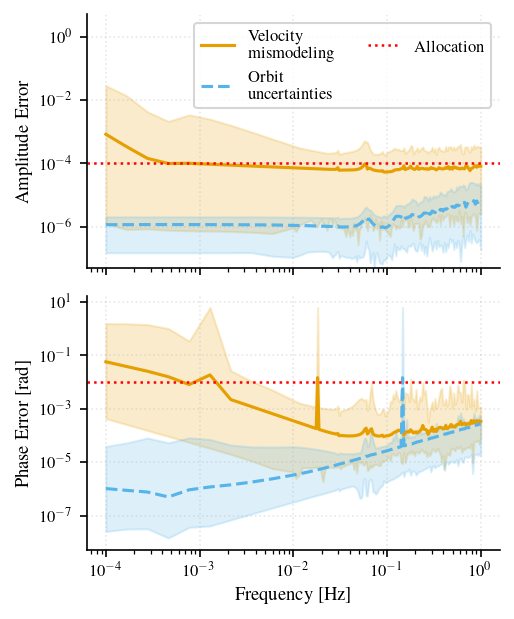

In [123]:
pols=('$h_+$', r'$h_\times$')

fig, axs = plt.subplots(2, 1, figsize=(COL1, 1.2*COL1), sharex=True)

ch = 0
pol = 0
labels = ['Velocity\nmismodeling', 'Orbit\nuncertainties']
linestyle = ['-', '--']

for i, name in enumerate(['Realistic (no boost)', 'Realistic (boost)']):
    data = all_data[name]
    
    # Full results: (F, N_real, 3, 2) - compute means and min/max
    amp_err = data["strain2x_avg_rel_amp_error"]  # (F, N_real, 3, 2)
    freq_mean_abs = np.mean(amp_err, axis=1)[:, ch, pol]
    freq_min = np.min(amp_err, axis=1)[:, ch, pol]
    freq_max = np.max(amp_err, axis=1)[:, ch, pol]
    
    axs[0].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[0].loglog(f, freq_mean_abs, label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    
    # Phase errors
    angle_err = data["strain2x_angle_error"]  # (F, N_real, 3, 2)
    freq_mean_angle = np.mean(angle_err, axis=1)[:, ch, pol]
    freq_min = np.min(angle_err, axis=1)[:, ch, pol]
    freq_max = np.max(angle_err, axis=1)[:, ch, pol]
    
    axs[1].fill_between(f, freq_min, freq_max, alpha=0.2, color=f'C{i}')
    axs[1].loglog(f, freq_mean_angle, label=labels[i], color=f'C{i}', linestyle=linestyle[i])
    
    # Summary statistics
    print(f"{labels[i]}:")
    f_test = np.asarray([1e-4, 1e-3, 1e-2, 1])
    for tf in f_test:
            print(f"  Amplitude error at {tf*1000:.2f} mHz: {np.interp(tf, f, freq_mean_abs):.2e}")
            print(f"  Phase error at {tf*1000:.2f} mHz: {np.interp(tf, f, freq_mean_angle):.2e}")

axs[0].axhline(1e-4, color='r', ls=':', lw=1.2, label="Allocation")
axs[0].set_ylabel("Amplitude Error")
# axs[0].loglog(f, 1e-5/f, color='k', ls=linestyle[0], lw=1.2, label=r"$\propto f^{-1}$", alpha=0.5)
# axs[0].loglog(f, 1e-5*f, color='k', ls=linestyle[1], lw=1.2, label=r"$\propto f$", alpha=0.5)
axs[0].legend(ncol=2, title_fontsize=10)#, bbox_to_anchor=(1., 1.2))
axs[0].set_ylim(0.5e-7, 5)
axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel("Phase Error [rad]")
axs[1].axhline(1e-2, color='r', ls=':', lw=1.2, label="Allocation")
plt.tight_layout()
plt.savefig("paper_plots/requirement_amplitude_phase_errors.png", dpi=300)

# 3. Mismatch vs GW Frequency

The mismatch $\mathcal{M} = 1 - \langle h_\mathrm{pert}, h_\mathrm{nom} \rangle / \sqrt{\langle h_\mathrm{pert}, h_\mathrm{pert}\rangle\,\langle h_\mathrm{nom}, h_\mathrm{nom}\rangle}$
measures the overlap degradation caused by orbit perturbations.


Arm-length (boost) mismatch shape: (1000, 150, 432, 2)
Arm-length (boost) - $h_+$: Mismatch at 0.10 mHz = 7.45e-13
Arm-length (boost) - $h_+$: Mismatch at 1.00 mHz = 7.20e-16
Arm-length (boost) - $h_+$: Mismatch at 10.00 mHz = 8.69e-17
Arm-length (boost) - $h_+$: Mismatch at 100.00 mHz = 8.09e-17
Arm-length (boost) - $h_\times$: Mismatch at 0.10 mHz = 7.04e-13
Arm-length (boost) - $h_\times$: Mismatch at 1.00 mHz = 6.76e-16
Arm-length (boost) - $h_\times$: Mismatch at 10.00 mHz = 8.05e-17
Arm-length (boost) - $h_\times$: Mismatch at 100.00 mHz = 7.34e-17
Translation (boost) mismatch shape: (1000, 150, 432, 2)
Translation (boost) - $h_+$: Mismatch at 0.10 mHz = 5.68e-15
Translation (boost) - $h_+$: Mismatch at 1.00 mHz = 6.04e-13
Translation (boost) - $h_+$: Mismatch at 10.00 mHz = 5.67e-11
Translation (boost) - $h_+$: Mismatch at 100.00 mHz = 5.67e-09
Translation (boost) - $h_\times$: Mismatch at 0.10 mHz = 5.35e-15
Translation (boost) - $h_\times$: Mismatch at 1.00 mHz = 5.70e-13
Tran

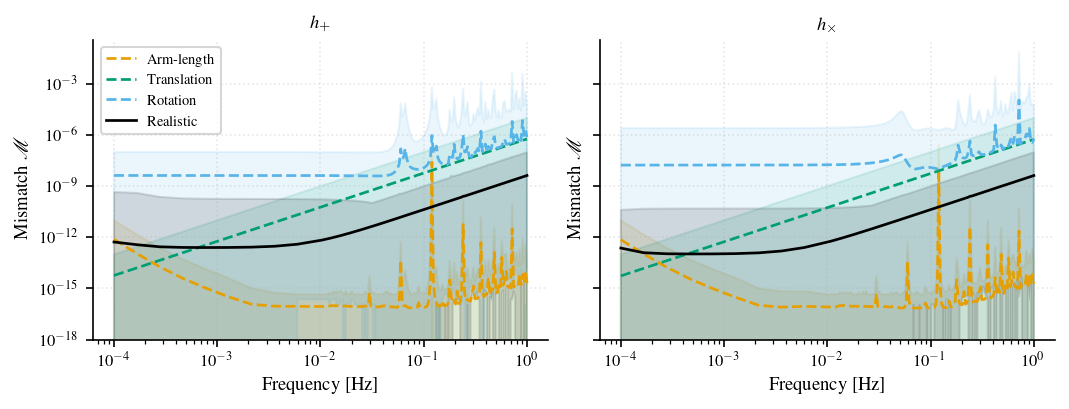

In [124]:
# Colorblind-friendly palette (Wong 2011)
STYLES = {
    "Arm-length (boost)":             dict(color=COLORBLIND_PALETTE[0], ls="--", lw=1.3),
    "Translation (boost)":     dict(color=COLORBLIND_PALETTE[2], ls="--", lw=1.3),
    "Rotation (boost)":        dict(color=COLORBLIND_PALETTE[1], ls="--", lw=1.3),
    # "Toy like realistic (boost)": dict(color=COLORBLIND_PALETTE[4], ls="--", lw=1.3), # add this if you want check how the toy like realistic case compares to the realistic one
    "Realistic (boost)":    dict(color="k", ls="-", lw=1.3),
}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharex=True, sharey=True)

for label, style in STYLES.items():
    if label not in all_data:
        continue
    
    mm = np.nan_to_num(all_data[label]["mismatch"])  # (N_real, F, sky, 2)
    print(f"{label} mismatch shape: {mm.shape}")
    freq_mean = mm.mean(axis=(0, 2))   # (F, 2)
    freq_min  = mm.min(axis=(0, 2))    # (F, 2)
    freq_max  = mm.max(axis=(0, 2))    # (F, 2)
    
    for j, ax in enumerate(axes):
        ax.fill_between(f, freq_min[:, j], freq_max[:, j],
                        color=style["color"], alpha=0.12)
        ax.plot(f, freq_mean[:, j],
                ls=style["ls"], lw=style["lw"], color=style["color"],
                label=label[:-8] if j == 0 else None)
        # print(np.sum((freq_min[:, j] < freq_mean[:, j]) * (freq_mean[:, j] < freq_max[:, j]))/freq_mean[:, j].size)
        for test_f in [1e-4, 1e-3, 1e-2, 1e-1]:
            print(f"{label} - {POLS[j]}: Mismatch at {test_f*1000:.2f} mHz = {np.interp(test_f, f, freq_mean[:, j]):.2e}")

for j, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"Mismatch $\mathcal{M}$")
    ax.set_title(POLS[j])
    ax.set_ylim(bottom=1e-18)

axes[0].legend(fontsize=7, ncol=1, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "mismatch_vs_frequency.png"), dpi=300)
plt.show()

Arm-length (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Arm-length (boost) - $h_+$: Mismatch at 1 mHz = 7.20e-16
Arm-length (boost) - $h_+$: Mismatch at 100 mHz = 8.09e-17
1.0
Arm-length (boost) - $h_\times$: Mismatch at 1 mHz = 6.76e-16
Arm-length (boost) - $h_\times$: Mismatch at 100 mHz = 7.34e-17
Rotation (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Rotation (boost) - $h_+$: Mismatch at 1 mHz = 4.10e-09
Rotation (boost) - $h_+$: Mismatch at 100 mHz = 1.15e-08
1.0
Rotation (boost) - $h_\times$: Mismatch at 1 mHz = 1.66e-08
Rotation (boost) - $h_\times$: Mismatch at 100 mHz = 1.21e-08
Translation (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Translation (boost) - $h_+$: Mismatch at 1 mHz = 6.04e-13
Translation (boost) - $h_+$: Mismatch at 100 mHz = 5.67e-09
1.0
Translation (boost) - $h_\times$: Mismatch at 1 mHz = 5.70e-13
Translation (boost) - $h_\times$: Mismatch at 100 mHz = 5.35e-09
Toy like realistic (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Toy-model calibrated to

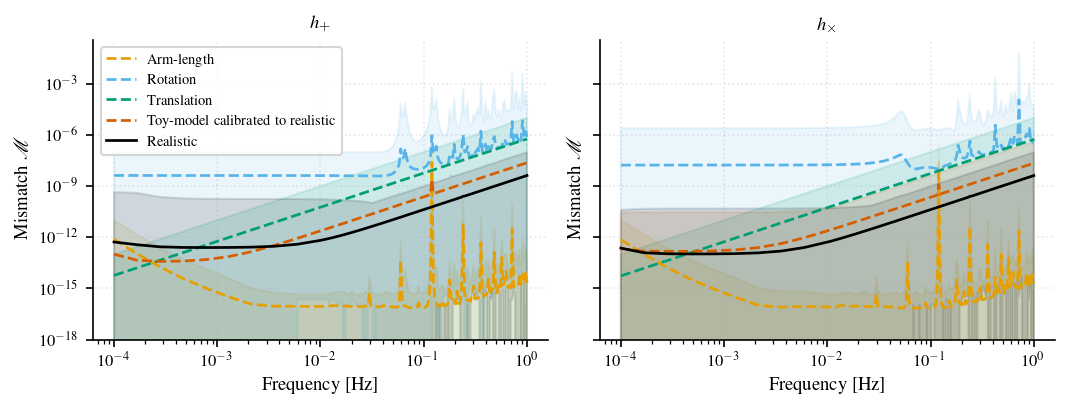

In [125]:
# Colorblind-friendly palette (Wong 2011)
STYLES = {
    "Arm-length (boost)":             dict(color=COLORBLIND_PALETTE[0], ls="--", lw=1.3),
    "Rotation (boost)":        dict(color=COLORBLIND_PALETTE[1], ls="--", lw=1.3),
    "Translation (boost)":     dict(color=COLORBLIND_PALETTE[2], ls="--", lw=1.3),
    "Toy like realistic (boost)": dict(color=COLORBLIND_PALETTE[5], ls="--", lw=1.3), # add this if you want check how the toy like realistic case compares to the realistic one
    "Realistic (boost)":    dict(color="k", ls="-", lw=1.3),
}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharex=True, sharey=True)

for label, style in STYLES.items():
    if label not in all_data:
        continue
    
    mm = np.nan_to_num(all_data[label]["mismatch"])  # (N_real, F, sky, 2)
    print(f"{label} mismatch shape: {mm.shape}")
    freq_mean = mm.mean(axis=(0, 2))   # (F, 2)
    freq_min  = mm.min(axis=(0, 2))    # (F, 2)
    freq_max  = mm.max(axis=(0, 2))    # (F, 2)
    
    for j, ax in enumerate(axes):
        if label == "Toy like realistic (boost)":
            label = "Toy-model calibrated to realistic (boost)"
        else:
            ax.fill_between(f, freq_min[:, j], freq_max[:, j],
                        color=style["color"], alpha=0.12)
        ax.plot(f, freq_mean[:, j],
                ls=style["ls"], lw=style["lw"], color=style["color"],
                label=label[:-8] if j == 0 else None)
        print(np.sum((freq_min[:, j] < freq_mean[:, j]) * (freq_mean[:, j] < freq_max[:, j]))/freq_mean[:, j].size)
        print(f"{label} - {POLS[j]}: Mismatch at 1 mHz = {np.interp(1e-3, f, freq_mean[:, j]):.2e}")
        print(f"{label} - {POLS[j]}: Mismatch at 100 mHz = {np.interp(1e-1, f, freq_mean[:, j]):.2e}")

for j, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"Mismatch $\mathcal{M}$")
    ax.set_title(POLS[j])
    ax.set_ylim(bottom=1e-18)

axes[0].legend(fontsize=7, ncol=1, loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, "mismatch_vs_frequency_toy_like_realistic.png"), dpi=300)
plt.show()

Arm-length (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Arm-length (boost) - $h_+$: Mismatch at 1 mHz = 7.20e-16
Arm-length (boost) - $h_+$: Mismatch at 100 mHz = 8.09e-17
1.0
Arm-length (boost) - $h_\times$: Mismatch at 1 mHz = 6.76e-16
Arm-length (boost) - $h_\times$: Mismatch at 100 mHz = 7.34e-17
Rotation (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Rotation (boost) - $h_+$: Mismatch at 1 mHz = 4.10e-09
Rotation (boost) - $h_+$: Mismatch at 100 mHz = 1.15e-08
1.0
Rotation (boost) - $h_\times$: Mismatch at 1 mHz = 1.66e-08
Rotation (boost) - $h_\times$: Mismatch at 100 mHz = 1.21e-08
Translation (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Translation (boost) - $h_+$: Mismatch at 1 mHz = 6.04e-13
Translation (boost) - $h_+$: Mismatch at 100 mHz = 5.67e-09
1.0
Translation (boost) - $h_\times$: Mismatch at 1 mHz = 5.70e-13
Translation (boost) - $h_\times$: Mismatch at 100 mHz = 5.35e-09
Toy like realistic (boost) mismatch shape: (1000, 150, 432, 2)
1.0
Toy-model calibrated to

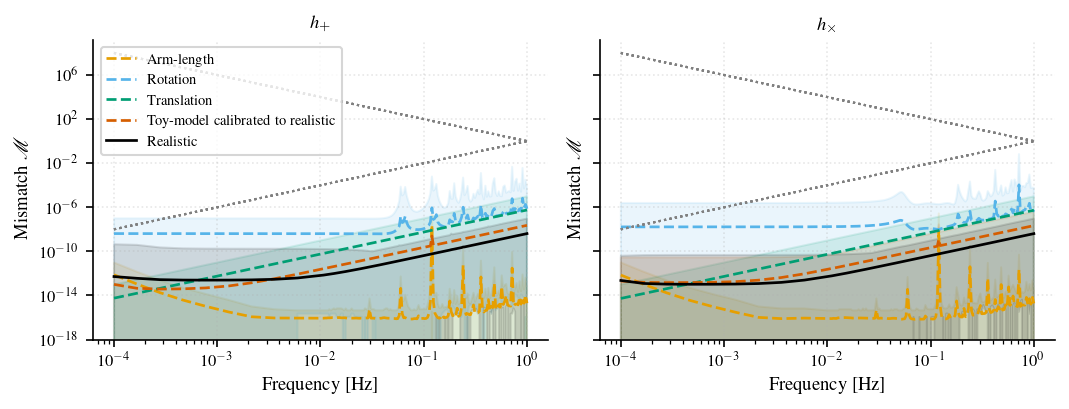

In [126]:
# Colorblind-friendly palette (Wong 2011)
STYLES = {
    "Arm-length (boost)":             dict(color=COLORBLIND_PALETTE[0], ls="--", lw=1.3),
    "Rotation (boost)":        dict(color=COLORBLIND_PALETTE[1], ls="--", lw=1.3),
    "Translation (boost)":     dict(color=COLORBLIND_PALETTE[2], ls="--", lw=1.3),
    "Toy like realistic (boost)": dict(color=COLORBLIND_PALETTE[5], ls="--", lw=1.3), # add this if you want check how the toy like realistic case compares to the realistic one
    "Realistic (boost)":    dict(color="k", ls="-", lw=1.3),
}

fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharex=True, sharey=True)

for label, style in STYLES.items():
    if label not in all_data:
        continue
    
    mm = np.nan_to_num(all_data[label]["mismatch"])  # (N_real, F, sky, 2)
    print(f"{label} mismatch shape: {mm.shape}")
    freq_mean = mm.mean(axis=(0, 2))   # (F, 2)
    freq_min  = mm.min(axis=(0, 2))    # (F, 2)
    freq_max  = mm.max(axis=(0, 2))    # (F, 2)
    
    for j, ax in enumerate(axes):
        if label == "Toy like realistic (boost)":
            label = "Toy-model calibrated to realistic (boost)"
        else:
            ax.fill_between(f, freq_min[:, j], freq_max[:, j],
                        color=style["color"], alpha=0.12)
        ax.plot(f, freq_mean[:, j],
                ls=style["ls"], lw=style["lw"], color=style["color"],
                label=label[:-8] if j == 0 else None)
        ax.plot(f, f**2, ls=":", lw=1, color="gray")
        ax.plot(f, f**-2, ls=":", lw=1, color="gray")
        print(np.sum((freq_min[:, j] < freq_mean[:, j]) * (freq_mean[:, j] < freq_max[:, j]))/freq_mean[:, j].size)
        print(f"{label} - {POLS[j]}: Mismatch at 1 mHz = {np.interp(1e-3, f, freq_mean[:, j]):.2e}")
        print(f"{label} - {POLS[j]}: Mismatch at 100 mHz = {np.interp(1e-1, f, freq_mean[:, j]):.2e}")

for j, ax in enumerate(axes):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel(r"Mismatch $\mathcal{M}$")
    ax.set_title(POLS[j])
    ax.set_ylim(bottom=1e-18)
    

axes[0].legend(fontsize=7, ncol=1, loc="upper left")
plt.tight_layout()
# plt.savefig(os.path.join(PAPER_DIR, "mismatch_vs_frequency_toy_like_realistic.png"), dpi=300)
plt.show()

## Mismatch Sky Maps

In [127]:
all_data.keys()

dict_keys(['Arm-length (no boost)', 'Arm-length (boost)', 'Rotation (no boost)', 'Rotation (boost)', 'Translation (no boost)', 'Translation (boost)', 'Realistic (no boost)', 'Realistic (boost)', 'Toy like realistic (boost)'])


Processing case: Realistic (boost)


/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


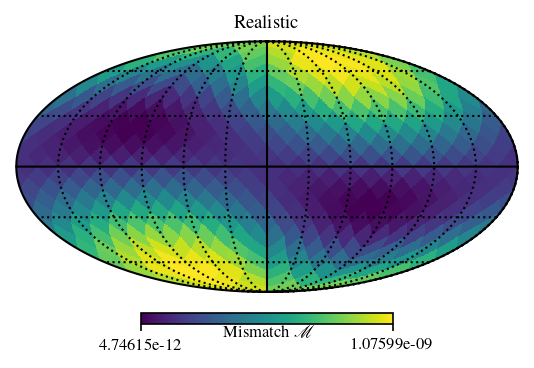

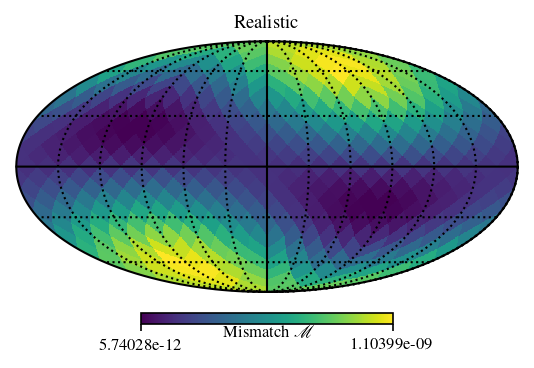


Processing case: Arm-length (boost)


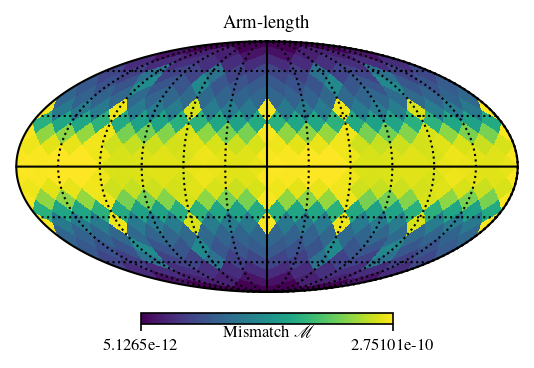

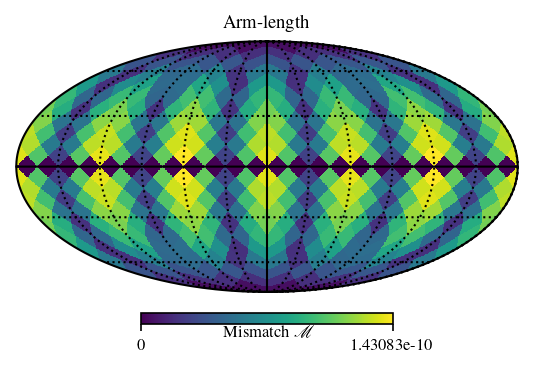


Processing case: Rotation (boost)


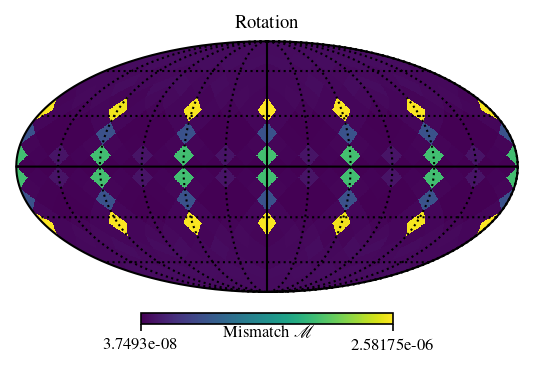

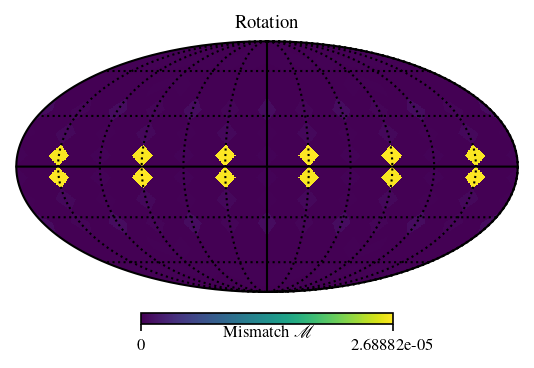


Processing case: Translation (boost)


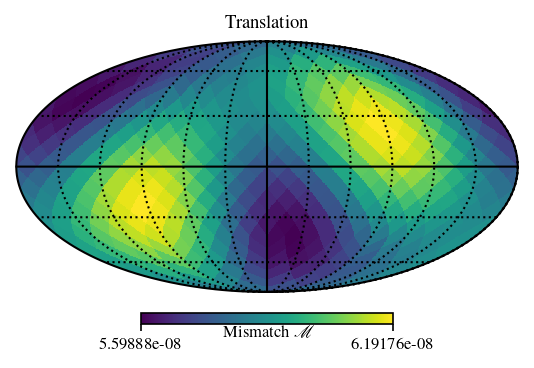

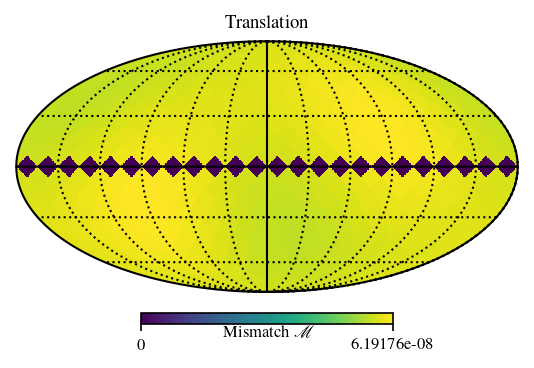

In [128]:
for MAP_CASE in ["Realistic (boost)", "Arm-length (boost)", "Rotation (boost)", "Translation (boost)"]:
    print("="*60)
    print(f"\nProcessing case: {MAP_CASE}")
    d    = all_data[MAP_CASE]
    mm   = np.nan_to_num(d["mismatch"])   # (N, F, P, 2)
    npix = d["npix"]

    # ── Mollweide sky maps ───────────────────────────────────────────────────────
    for j, pol in enumerate(POLS):
        sky_map = mm.mean(axis=(0, 1))[:, j]   # (P,) – max over realisations & freq
        fig = plt.figure(figsize=(COL1, 3))
        hp.mollview(
            sky_map,
            title=f"{MAP_CASE[:-8]}",
            rot=[0, 0], 
            fig=fig.number,
            unit=r"Mismatch $\mathcal{M}$",
            fontsize={'cbar_label': 8},
        )
        hp.graticule()
        fname = f"mismatch_sky_{pol.replace('$','').replace('_','').replace('+','p').replace('\\times','x')}.png"
        plt.show()

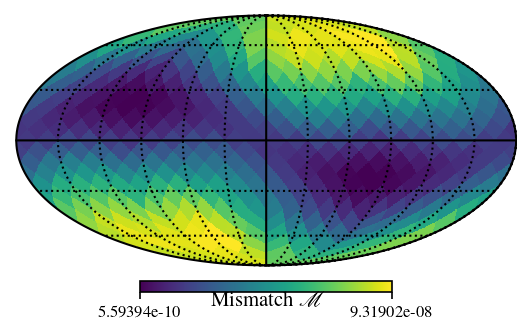

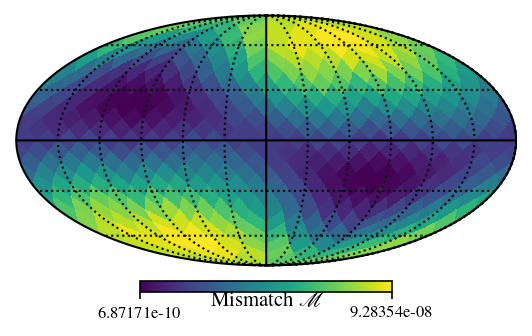

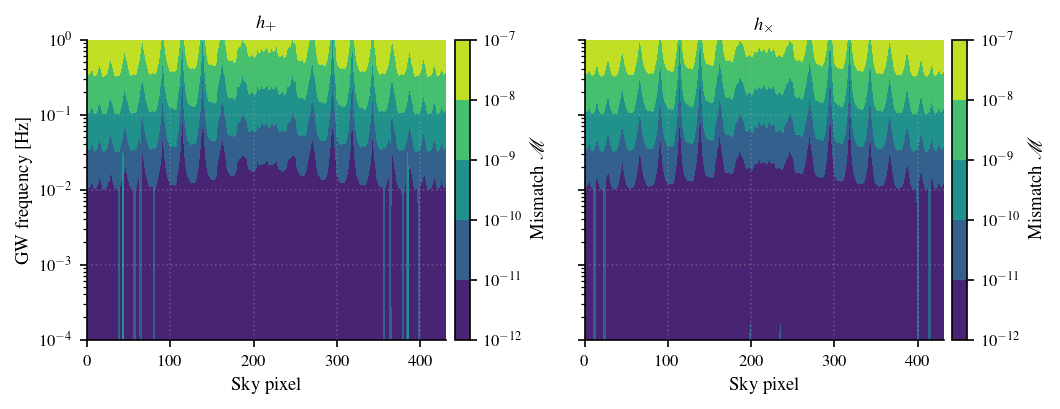

In [129]:
MAP_CASE = "Realistic (boost)"
d    = all_data[MAP_CASE]
mm   = np.nan_to_num(d["mismatch"])   # (N, F, P, 2)
npix = d["npix"]

# ── Mollweide sky maps ───────────────────────────────────────────────────────
for j, pol in enumerate(POLS):
    sky_map = mm.max(axis=(0, 1))[:, j]   # (P,) – max over realisations & freq
    fig = plt.figure(figsize=(COL1, 2.2))
    hp.mollview(
        sky_map,
        title=f"",
        rot=[0, 0], 
        fig=fig.number,
        unit=r"Mismatch $\mathcal{M}$",
        fontsize={'xlabel': 10, 'ylabel': 10, 'title': 10, 'cbar_label': 10},
    )
    hp.graticule()
    fname = f"mismatch_sky_{pol.replace('$','').replace('_','').replace('+','p').replace('\\times','x')}.pdf"
    plt.show()

# ── Frequency–sky contour ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(COL2, 2.8), sharey=True)

for j, (ax, pol) in enumerate(zip(axes, POLS)):
    z = mm.max(axis=0)[:, :, j]         # (F, P) – max over realisations
    vmin = max(1e-12, float(z.min()))
    vmax = min(1.0,   float(z.max()))
    z = z.clip(vmin, vmax)
    dmin = int(np.floor(np.log10(vmin)))
    dmax = int(np.ceil(np.log10(vmax)))
    levels = np.logspace(dmin, dmax, max(2, dmax - dmin + 1))
    cf = ax.contourf(
        np.arange(npix), f, z,
        levels=levels, norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Sky pixel")
    ax.set_title(pol)
    cbar = fig.colorbar(cf, ax=ax, pad=0.02)
    cbar.set_label(r"Mismatch $\mathcal{M}$")

axes[0].set_ylabel("GW frequency [Hz]")
plt.tight_layout()
plt.show()

# Mismatch of Galactic Binary

<KeysViewHDF5 ['f0_vec', 'mismatch_nonrel_vs_rel_test', 'mismatch_nonrel_vs_rel_with_nominal', 'mismatch_nonrel_vs_rel_with_perturbed', 'mismatch_perturbed_vs_nominal_with_nonrel', 'mismatch_perturbed_vs_nominal_with_rel']>
Mismatch at 0.10 mHz for Perturbed vs Nominal Orbits: 1.05e-13
Mismatch at 1.00 mHz for Perturbed vs Nominal Orbits: 8.73e-14
Mismatch at 10.00 mHz for Perturbed vs Nominal Orbits: 6.20e-13
Mismatch at 100.00 mHz for Perturbed vs Nominal Orbits: 4.80e-11
Mismatch at 0.10 mHz for Non-Boosted vs Boosted Response: 4.17e-04
Mismatch at 1.00 mHz for Non-Boosted vs Boosted Response: 2.55e-05
Mismatch at 10.00 mHz for Non-Boosted vs Boosted Response: 1.53e-07
Mismatch at 100.00 mHz for Non-Boosted vs Boosted Response: 8.09e-09


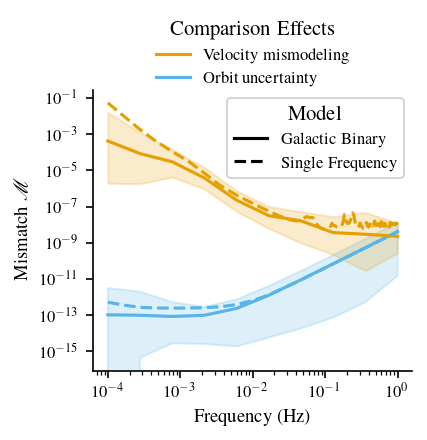

In [135]:
from matplotlib.lines import Line2D

output_file = f"data/gb_mismatch_results_30.0days.h5"

mismatch = {}
with h5py.File(output_file, "r") as f:
    print(f.keys())
    f0_vec = f["f0_vec"][()]
    for key in f.keys():
        if key.startswith("mismatch_"):
            mismatch[key] = f[key][()]

labels = {
    "mismatch_perturbed_vs_nominal_with_rel": "Perturbed vs Nominal Orbits",
    "mismatch_nonrel_vs_rel_with_nominal": "Non-Boosted vs Boosted Response",
}

plt.figure(figsize=(COL1/1.2, COL1/1.1))

key = "mismatch_perturbed_vs_nominal_with_rel"
y_mean = mismatch[key].mean(axis=1)
y_min = mismatch[key].min(axis=1)
y_max = mismatch[key].max(axis=1)
plt.fill_between(f0_vec, y_min, y_max, alpha=0.2, color='C1')
plt.plot(f0_vec, y_mean, '-', label=labels[key], color='C1')
for test_f in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"Mismatch at {test_f*1000:.2f} mHz for {labels['mismatch_perturbed_vs_nominal_with_rel']}: {np.interp(test_f, f0_vec, y_mean):.2e}")

key = "mismatch_nonrel_vs_rel_with_nominal"
y_mean = mismatch[key].mean(axis=1)
y_min = mismatch[key].min(axis=1)
y_max = mismatch[key].max(axis=1)
plt.fill_between(f0_vec, y_min, y_max, alpha=0.2, color='C0')
plt.plot(f0_vec, y_mean, '-', label=labels[key], color='C0')

for test_f in [1e-4, 1e-3, 1e-2, 1e-1]:
    print(f"Mismatch at {test_f*1000:.2f} mHz for {labels['mismatch_nonrel_vs_rel_with_nominal']}: {np.interp(test_f, f0_vec, y_mean):.2e}")

f = all_data["Realistic (no boost)"]["f"]
mm_no_boost = np.nan_to_num(all_data["Realistic (no boost)"]["mismatch"])
mean_no_boost = mm_no_boost.mean(axis=(0, 2))[:, 0]

mm_boost = np.nan_to_num(all_data["Realistic (boost)"]["mismatch"])
mean_boost = mm_boost.mean(axis=(0, 2))[:, 0]

plt.loglog(f, mean_no_boost, ls='--', color='C0')
plt.loglog(f, mean_boost, ls='--', color='C1')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"Mismatch $\mathcal{M}$")
ax = plt.gca()

style_handles = [
    Line2D([0], [0], color='k', ls='-', label='Galactic Binary'),
    Line2D([0], [0], color='k', ls='--', label='Single Frequency'),
]

color_handles = [
    Line2D([0], [0], color='C0', lw=1.5, label='Velocity mismodeling'),
    Line2D([0], [0], color='C1', lw=1.5, label='Orbit uncertainty'),
]

legend_style = ax.legend(handles=style_handles, title="Model", loc="upper right", title_fontsize=10)
ax.add_artist(legend_style)
ax.legend(handles=color_handles, title="Comparison Effects", loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=1, title_fontsize=10, frameon=True, framealpha=0.0)
plt.grid()
plt.tight_layout()
plt.savefig(os.path.join(PAPER_DIR, f"gb_mismatch_plot.png"), dpi=300, bbox_inches='tight')
plt.show()

<Figure size 262.5x262.5 with 0 Axes>

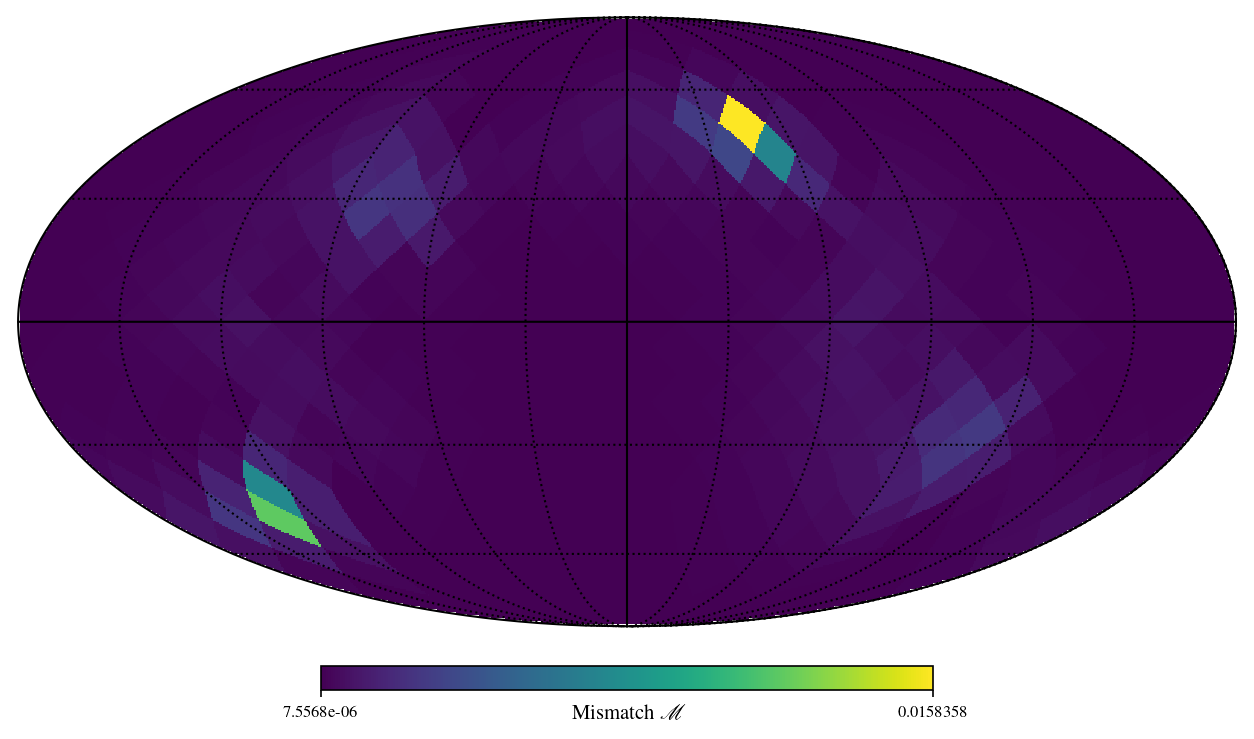

In [136]:
labels = {
    # "mismatch_perturbed_vs_nominal_with_nonrel": "Perturbed vs Nominal Orbits (Non-Boosted Response)",
    "mismatch_perturbed_vs_nominal_with_rel": "Perturbed vs Nominal Orbits",
    # "mismatch_nonrel_vs_rel_with_perturbed": "Non-Boosted vs Boosted Response (Perturbed orbits)",
    "mismatch_nonrel_vs_rel_with_nominal": "Non-Boosted vs Boosted Response",
    # "mismatch_nonrel_vs_rel_test": "Non-Boosted. vs Boosted Response (Test)",
}

key = "mismatch_perturbed_vs_nominal_with_rel"
key = "mismatch_nonrel_vs_rel_with_nominal"

plt.figure(figsize=(COL1/2,COL1/2))
hp.mollview(
        mismatch[key].max(axis=0),
        title=f"",
        rot=[0, 0], 
        unit=r"Mismatch $\mathcal{M}$",
        fontsize={'xlabel': 10, 'ylabel': 10, 'title': 10, 'cbar_label': 10},
    )
hp.graticule()

# MCMC plots

In [30]:

# ── Load and display chain statistics ────────────────────────────────────────
processed_chains_file = "data/mcmc_chains_processed.h5"

with h5py.File(processed_chains_file, "r") as hf:
    injection_params = hf["injection_params"][()]
    param_labels = [s.decode() if isinstance(s, bytes) else s for s in hf["param_labels"][()]]
    
    print("=" * 80)
    print("MCMC CHAIN STATISTICS")
    print("=" * 80)
    
    for model in ["non_boosted", "boosted"]:
        group = hf[model]
        med = group["median"][()]
        std = group["std"][()]
        bias = group["bias"][()]
        bias_sigma = group["bias_sigma"][()]
        
        n_samp = group.attrs["n_samples"]
        print(f"\n{model.upper()}: {n_samp} samples after burn-in")
        print("-" * 80)
        print(f"{'Parameter':<25} {'Median':<15} {'Std':<15} {'Bias':<15} {'Bias (σ)':<10}")
        print("-" * 80)
        
        for i, lbl in enumerate(param_labels):
            print(f"{lbl:<25} {med[i]:.6e} {std[i]:.4e} {bias[i]:.4e} {bias_sigma[i]:>8.2f}")
    
    print("=" * 80)


MCMC CHAIN STATISTICS

NON_BOOSTED: 224000 samples after burn-in
--------------------------------------------------------------------------------
Parameter                 Median          Std             Bias            Bias (σ)  
--------------------------------------------------------------------------------
$f_0$ [Hz]                9.999980e-05 3.1402e-10 -1.9501e-10    -0.62
$\dot f_0$ [Hz/s]         5.010473e-19 2.7532e-19 5.0105e-19     1.82
$A$                       5.258129e-19 1.2931e-20 -3.4700e-21    -0.27
$\beta$                   -1.016380e+00 1.0810e-02 3.1307e-03     0.29
$\lambda$                 9.801640e-01 1.8115e-02 -1.5837e-03    -0.09
$\psi$                    2.642887e+00 1.3893e+00 1.5957e+00     1.15
$\iota$                   1.047070e+00 2.0690e-02 -1.2739e-04    -0.01
$\phi_0$                  4.133880e+00 1.4886e+00 3.0867e+00     2.07

BOOSTED: 224000 samples after burn-in
--------------------------------------------------------------------------------
Par


NON_BOOSTED
$f_0$ [Hz]: 9.9999804992e-05 ± 3.1402e-10, precision: 3.14e-06, bias: -1.9501e-10, bias in sigma: -0.62
$f_0$ [Hz]: relative bias: -1.9500813590062494e-06
$\dot f_0$ [Hz/s]: 5.0104729474e-19 ± 2.7532e-19, precision: nan, bias: 5.0105e-19, bias in sigma: 1.82
$\dot f_0$ [Hz/s]: relative bias: inf
$A$: 5.2581290397e-19 ± 1.2931e-20, precision: 2.44e-02, bias: -3.4700e-21, bias in sigma: -0.27
$A$: relative bias: -0.006555985854724063
$\beta$: -1.0163800162e+00 ± 1.0810e-02, precision: -1.06e-02, bias: 3.1307e-03, bias in sigma: 0.29
$\beta$: relative bias: -0.0030707986785353763
$\lambda$: 9.8016403361e-01 ± 1.8115e-02, precision: 1.85e-02, bias: -1.5837e-03, bias in sigma: -0.09
$\lambda$: relative bias: -0.0016131136602570498
$\psi$: 2.6428865230e+00 ± 1.3893e+00, precision: 1.33e+00, bias: 1.5957e+00, bias in sigma: 1.15
$\psi$: relative bias: 1.5237707249575727
$\iota$: 1.0470701604e+00 ± 2.0690e-02, precision: 1.98e-02, bias: -1.2739e-04, bias in sigma: -0.01
$\iota$: r

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_19105/262206013.py:124: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"{lbl}: relative bias: {(med[i] - injection_params[i]) / injection_params[i]}")


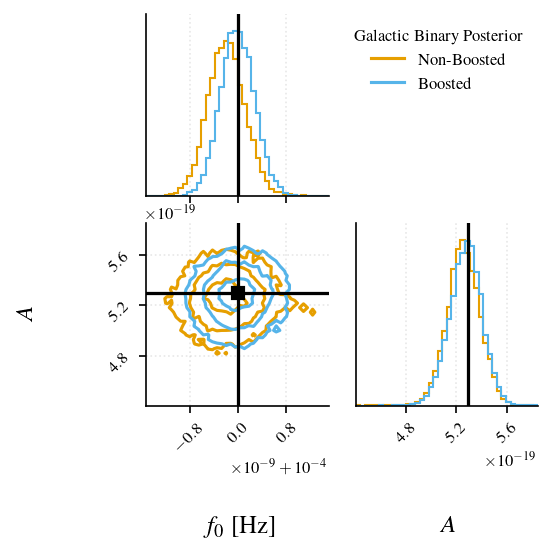

In [31]:

# ── Plot corner from processed chains HDF5 file ──────────────────────────────

processed_chains_file = "data/mcmc_chains_processed.h5"

# Setup
def get_normalisation_weight(n, n_ref):
    return np.ones(n) * (n_ref / n)

labels_full = np.array([
    r"$f_0$ [Hz]",
    r"$\dot f_0$ [Hz/s]",
    r"$A$",
    r"$\beta$",
    r"$\lambda$",
    r"$\psi$",
    r"$\iota$",
    r"$\phi_0$",
    r"$\log L$",
])

index_to_plot = np.asarray([0, 2], dtype=int)

with h5py.File(processed_chains_file, "r") as hf:
    injection_params = hf["injection_params"][()]

CORNER_KWARGS = dict(
    labels=labels_full[index_to_plot].tolist(),
    bins=40,
    truths=injection_params[index_to_plot],
    label_kwargs=dict(fontsize=12),
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    show_titles=False,
    max_n_ticks=4,
    truth_color="k",
    labelpad=0.3,
)

def overlaid_corner(samples_list, sample_labels, name_save=None, corn_kw=None, title=None, weights=None):
    import matplotlib.lines as mlines

    n = len(samples_list)
    _, ndim = samples_list[0].shape
    max_len = max(len(s) for s in samples_list)
    colors = ["C0", "C1"]

    plot_range = []
    for d in range(ndim):
        lo = min(np.min(samples_list[i][:, d]) for i in range(n))
        hi = max(np.max(samples_list[i][:, d]) for i in range(n))
        plot_range.append([lo, hi])

    corn_kw = {} if corn_kw is None else dict(corn_kw)
    corn_kw.update(range=plot_range)

    if weights is None:
        weights = [get_normalisation_weight(len(samples_list[i]), max_len) for i in range(n)]
    else:
        weights = [
            get_normalisation_weight(len(samples_list[i]), max_len) * weights[i]
            for i in range(n)
        ]
    fig = plt.figure(figsize=(COL1, COL1))
    fig = corner.corner(
        samples_list[0],
        fig=fig,
        color=colors[0],
        weights=weights[0],
        **corn_kw,
    )
    axes = np.array(fig.axes).reshape((ndim, ndim))
    maxy_all = [[axes[i, i].get_ybound()[-1] for i in range(ndim)]]

    for i in range(1, n):
        fig = corner.corner(samples_list[i], fig=fig, color=colors[i], weights=weights[i], **corn_kw)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        maxy_all.append([axes[j, j].get_ybound()[-1] for j in range(ndim)])

    maxy_all = np.asarray(maxy_all)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        axes[i, i].set_ylim(0.0, np.max(maxy_all[:, i]))

    axes[0,-1].legend(
        handles=[mlines.Line2D([], [], color=colors[i], label=sample_labels[i]) for i in range(n)],
        frameon=False,
        loc="upper right",
        title=title,
        fontsize=8,
        title_fontsize=8,
    )

    plt.subplots_adjust(hspace=0.15, wspace=0.15)

    if name_save is not None:
        plt.savefig(name_save + ".png", pad_inches=0.1, bbox_inches="tight", dpi=300)
    else:
        plt.show()

# Load and plot from HDF5
with h5py.File(processed_chains_file, "r") as hf:
    samples_list = []
    sample_labels = ["Non-Boosted", "Boosted"]
    
    for model in ["non_boosted", "boosted"]:
        group = hf[model]
        cold_samples = group["cold_samples"][()]
        cold_logl = group["cold_logl"][()]
        
        # Combine samples with log-likelihood and select indices to plot
        samp_log = np.hstack((cold_samples, cold_logl[:, np.newaxis]))
        samples_list.append(samp_log[:, index_to_plot])
        
        # Print statistics
        med = np.median(cold_samples, axis=0)
        std = np.std(cold_samples, axis=0)
        print(f"\n{model.upper()}")
        for i, lbl in enumerate(labels_full[:-1]):
            den = injection_params[i]
            prec = np.nan if (not np.isfinite(den) or den == 0) else std[i] / den
            print(f"{lbl}: {med[i]:.10e} ± {std[i]:.4e}, precision: {prec:.2e}, bias: {med[i] - injection_params[i]:.4e}, bias in sigma: {(med[i] - injection_params[i]) / std[i]:.2f}")
            print(f"{lbl}: relative bias: {(med[i] - injection_params[i]) / injection_params[i]}")

overlaid_corner(
    samples_list=samples_list,
    sample_labels=sample_labels,
    name_save=os.path.join(PAPER_DIR, "mcmc_corner_overlay"),
    corn_kw=CORNER_KWARGS,
    title="Galactic Binary Posterior"
)


# MCMC Processing (Only if you have run the MCMC)

In [32]:
output_file = "data/gb_mismatch_results_30.0days.h5"
mismatch = {}
with h5py.File(output_file, "r") as f:
    f0_vec = f["f0_vec"][()]
    for key in f.keys():
        if key.startswith("mismatch_"):
            mismatch[key] = f[key][()]

nside        = 6
npix         = hp.nside2npix(nside)
thetas, phis = hp.pix2ang(nside, np.arange(npix))
betas, lambs = np.pi / 2 - thetas, phis
f0_vec = np.logspace(-4,0.0, num=10)

temp = mismatch["mismatch_nonrel_vs_rel_with_nominal"]
# Lowest frequency, worst sky location at that frequency
i_f = 0
sky_ind = np.argmax(temp, axis=1)[i_f]
ind = (i_f, sky_ind)
print(f"Injection: f0_vec[{i_f}] = {f0_vec[i_f]:.4e} Hz, sky_ind = {sky_ind}, mismatch = {temp[i_f, sky_ind]:.6f}")

injection_source_params = np.array([
            f0_vec[ind[0]],                          # f0 (Hz)
            0.0,                           # fdot (Hz/s) - no evolution
            5.292828750112632e-19,                         # amplitude (strain)
            betas[ind[1]],                           # ecliptic latitude (rad)
            lambs[ind[1]],                           # ecliptic longitude (rad)
            np.pi/3,                           # polarization (rad)
            np.pi/3,                       # inclination (rad)
            np.pi/3,                           # initial phase (rad)
            np.nan,                           
])
injection_source_params

Injection: f0_vec[0] = 1.0000e-04 Hz, sky_ind = 57, mismatch = 0.015836


array([1.00000000e-04, 0.00000000e+00, 5.29282875e-19, 8.76522482e-01,
       5.49778714e+00, 1.04719755e+00, 1.04719755e+00, 1.04719755e+00,
                  nan])

In [33]:
!ls data/

backend_run_nonrel_15.0days_SNR37.20.h5
backend_run_nonrel_30.0days_SNR100.00_f1.00e-04.h5
backend_run_nonrel_365.0days_SNR100.00_f2.15e-03.h5
backend_run_nonrel_365days_SNR100.00.h5
backend_run_rel_15.0days_SNR37.20.h5
backend_run_rel_30.0days_SNR100.00_f1.00e-04.h5
backend_run_rel_365.0days_SNR100.00_f2.15e-03.h5
backend_run_rel_365days_SNR100.00.h5
gb_bias_results_15.0days.h5
gb_mismatch_results_15.0days.h5
gb_mismatch_results_30.0days.h5
gb_mismatch_results_365.0days.h5
link_response_maps.h5
mcmc_chains_processed.h5
old_frame_traj.h5
phase_evolution_plot.h5
processed_trajectories.h5
response_evolution_plot.h5
segwo_results_lightweight.h5
segwo_results_processed.h5
segwo_sky_maps.h5


In [34]:

def get_normalisation_weight(len_current_samples, len_of_longest_samples):
    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)

# data_nonrel = HDFBackend("data/backend_run_nonrel_30.0days_SNR37.20.h5")
# data_rel = HDFBackend("data/backend_run_rel_30.0days_SNR37.20.h5")
data_nonrel = HDFBackend("data/backend_run_nonrel_30.0days_SNR100.00_f1.00e-04.h5")
data_rel = HDFBackend("data/backend_run_rel_30.0days_SNR100.00_f1.00e-04.h5")


# data_nonrel = HDFBackend("data/backend_run_nonrel_365.0days_SNR100.00_f2.15e-03.h5")
# data_rel = HDFBackend("data/backend_run_rel_365.0days_SNR100.00_f2.15e-03.h5")


Non-Boosted
$f_0$ [Hz]: 1.0005098468e-04 ± 2.8247e-08, precision: 2.82e-04, bias: 5.0985e-08, bias in sigma: 1.80
$\dot f_0$ [Hz/s]: 4.9146084537e-19 ± 2.8000e-19, precision: nan, bias: 4.9146e-19, bias in sigma: 1.76
$A$: 9.6807033660e-19 ± 2.9150e-19, precision: 5.51e-01, bias: 4.3879e-19, bias in sigma: 1.51
$\beta$: 5.7468599545e-01 ± 6.2022e-01, precision: 7.08e-01, bias: -3.0184e-01, bias in sigma: -0.49
$\lambda$: 2.9476796789e+00 ± 3.0203e-01, precision: 5.49e-02, bias: -2.5501e+00, bias in sigma: -8.44
$\psi$: 3.5149450294e+00 ± 2.0152e-01, precision: 1.92e-01, bias: 2.4677e+00, bias in sigma: 12.25
$\iota$: 1.5567755511e+00 ± 2.9724e-01, precision: 2.84e-01, bias: 5.0958e-01, bias in sigma: 1.71
$\phi_0$: 4.0339947037e+00 ± 3.5571e-01, precision: 3.40e-01, bias: 2.9868e+00, bias in sigma: 8.40

Boosted
$f_0$ [Hz]: 1.0004914897e-04 ± 3.0783e-08, precision: 3.08e-04, bias: 4.9149e-08, bias in sigma: 1.60
$\dot f_0$ [Hz/s]: 5.0392458340e-19 ± 2.7184e-19, precision: nan, bias: 5

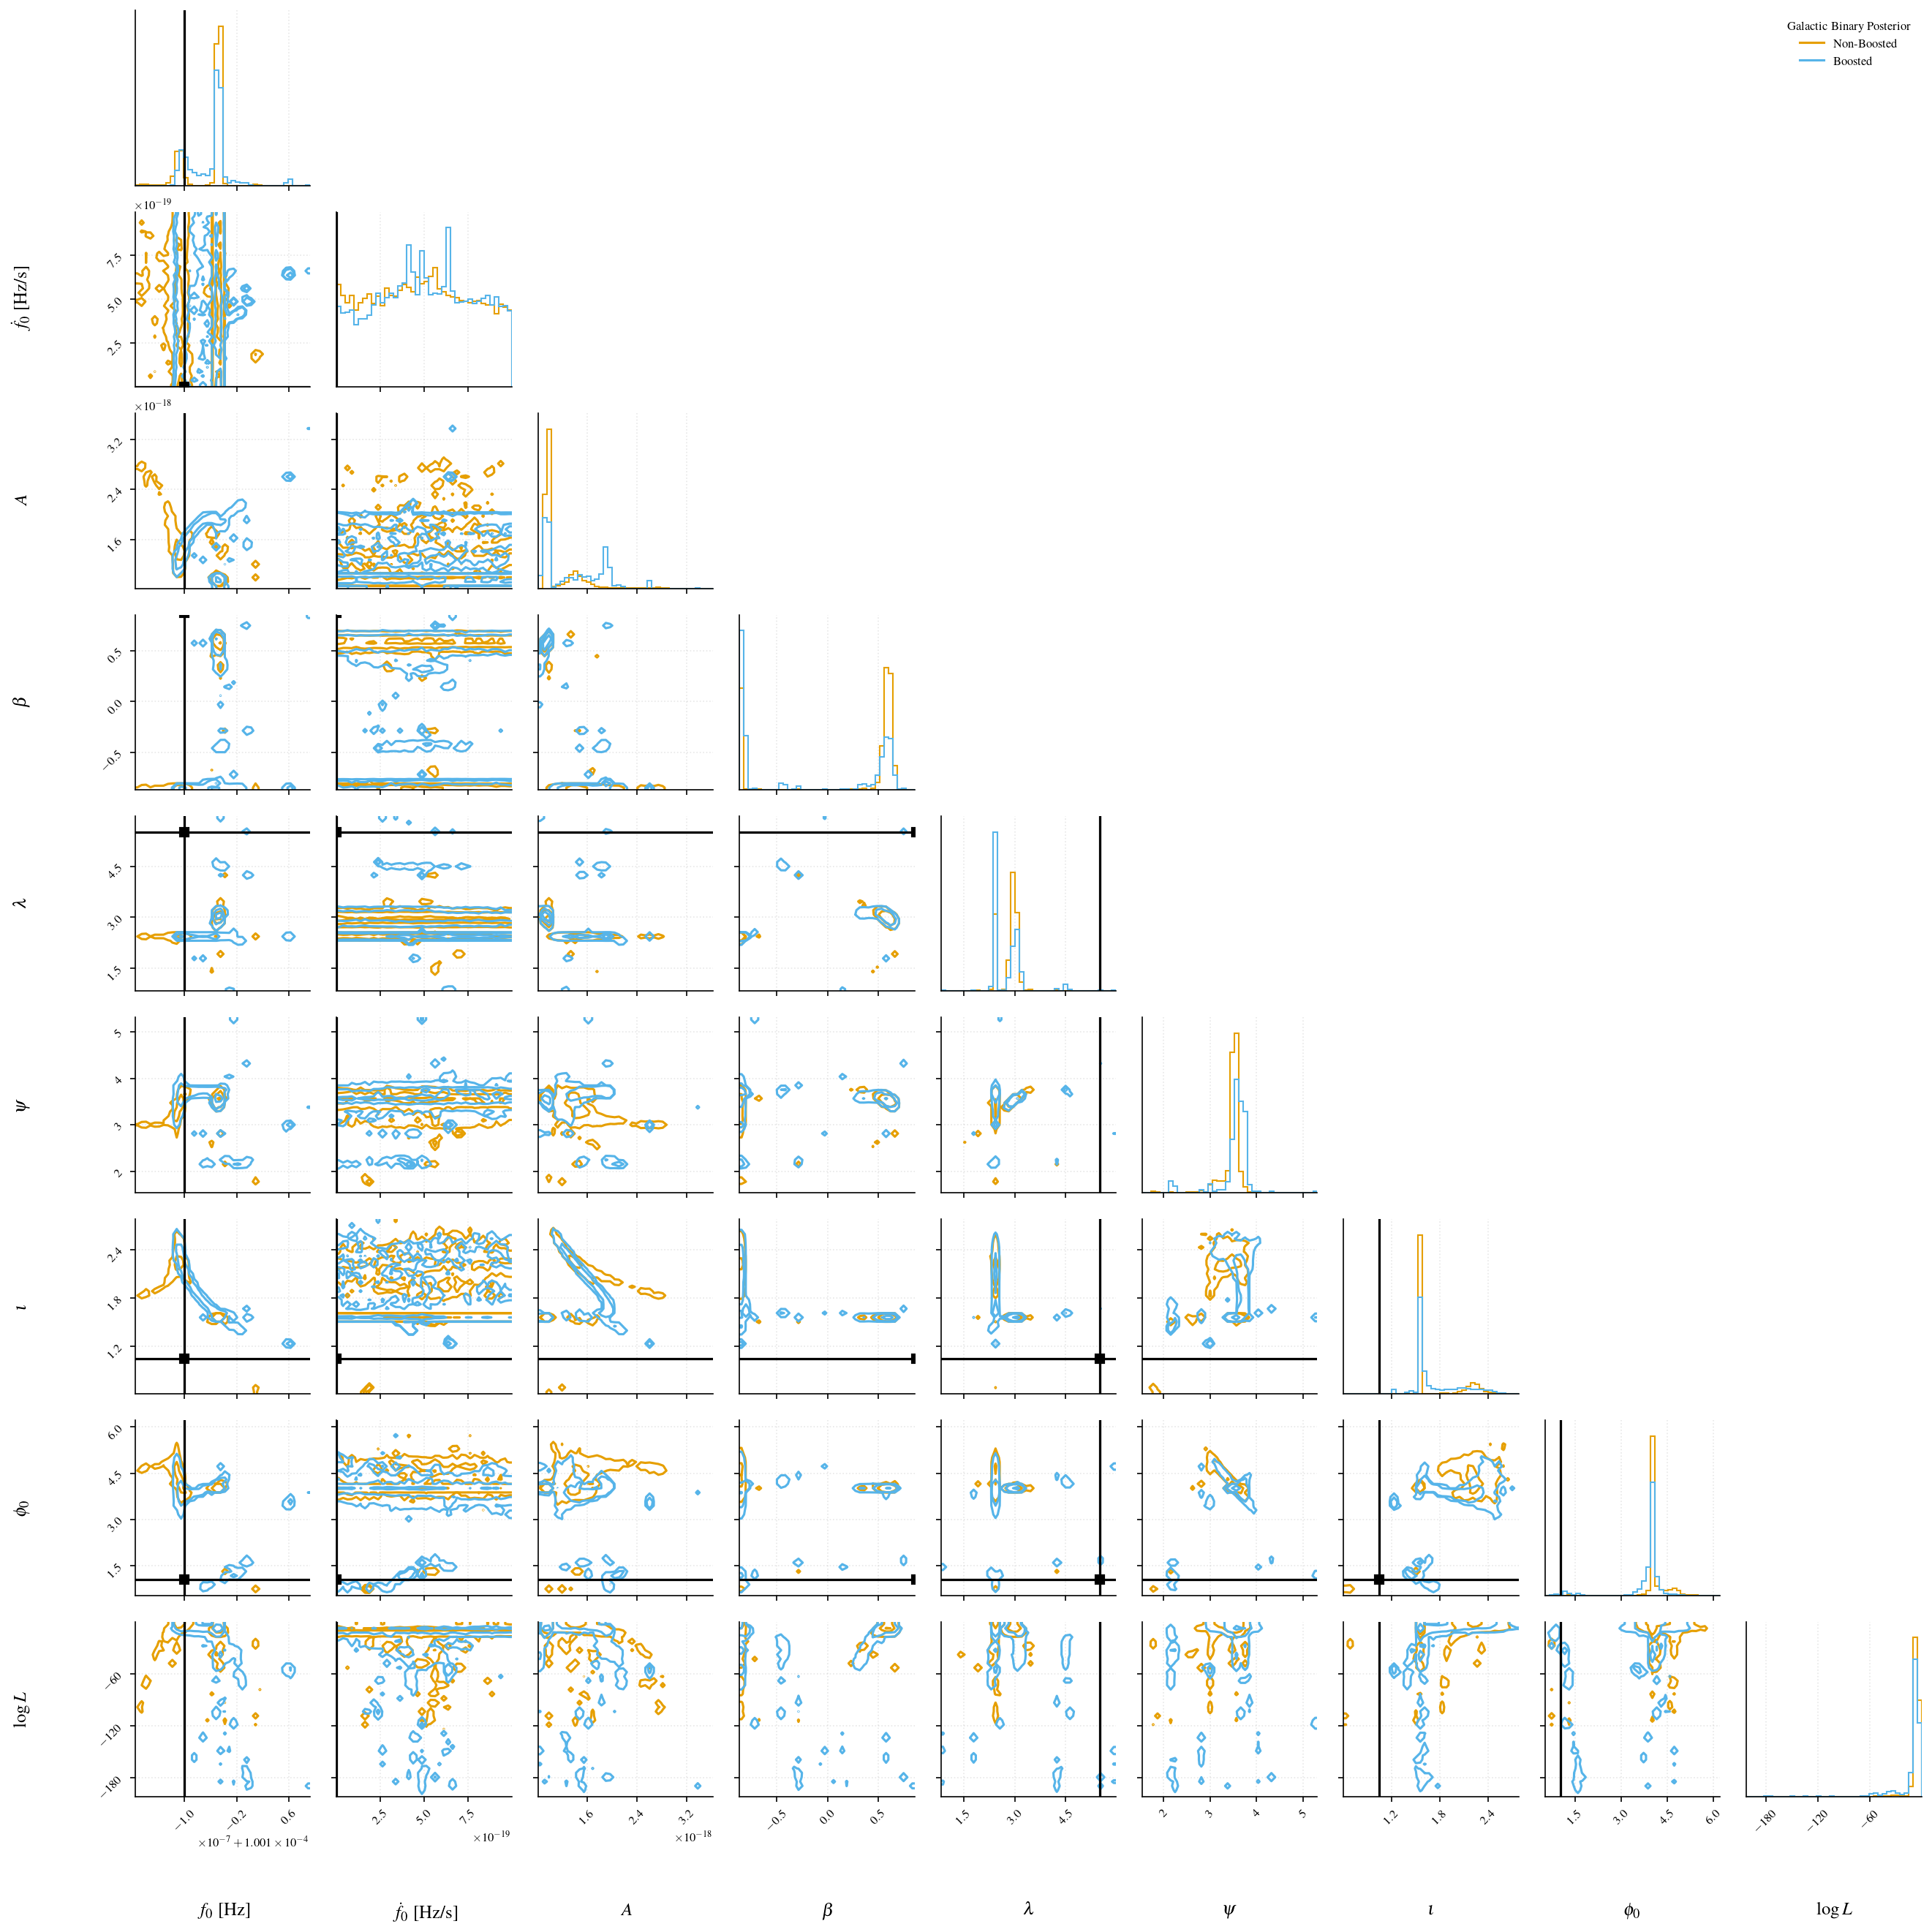

In [35]:
labels_full = np.array([
    r"$f_0$ [Hz]",
    r"$\dot f_0$ [Hz/s]",
    r"$A$",
    r"$\beta$",
    r"$\lambda$",
    r"$\psi$",
    r"$\iota$",
    r"$\phi_0$",
    r"$\log L$",
])

index_to_plot = np.arange(len(labels_full))#[np.array([0, 2], dtype=int)]

CORNER_KWARGS = dict(
    labels=labels_full[index_to_plot].tolist(),
    bins=40,
    truths=injection_source_params[index_to_plot],
    label_kwargs=dict(fontsize=12),
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=False,
    show_titles=False,
    max_n_ticks=4,
    truth_color="k",
    labelpad=0.3,
)


def overlaid_corner(samples_list, sample_labels, name_save=None, corn_kw=None, title=None, weights=None):
    import matplotlib.lines as mlines

    n = len(samples_list)
    _, ndim = samples_list[0].shape
    max_len = max(len(s) for s in samples_list)
    colors = ["C0", "C1"]

    plot_range = []
    for d in range(ndim):
        lo = min(np.min(samples_list[i][:, d]) for i in range(n))
        hi = max(np.max(samples_list[i][:, d]) for i in range(n))
        plot_range.append([lo, hi])

    corn_kw = {} if corn_kw is None else dict(corn_kw)
    corn_kw.update(range=plot_range)

    if weights is None:
        weights = [get_normalisation_weight(len(samples_list[i]), max_len) for i in range(n)]
    else:
        weights = [
            get_normalisation_weight(len(samples_list[i]), max_len) * weights[i]
            for i in range(n)
        ]
    fig = plt.figure(figsize=(COL1*5, COL1*5))
    fig = corner.corner(
        samples_list[0],
        fig=fig,
        color=colors[0],
        weights=weights[0],
        **corn_kw,
    )
    axes = np.array(fig.axes).reshape((ndim, ndim))
    maxy_all = [[axes[i, i].get_ybound()[-1] for i in range(ndim)]]

    for i in range(1, n):
        fig = corner.corner(samples_list[i], fig=fig, color=colors[i], weights=weights[i], **corn_kw)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        maxy_all.append([axes[j, j].get_ybound()[-1] for j in range(ndim)])

    maxy_all = np.asarray(maxy_all)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        axes[i, i].set_ylim(0.0, np.max(maxy_all[:, i]))

    axes[0,-1].legend(
        handles=[mlines.Line2D([], [], color=colors[i], label=sample_labels[i]) for i in range(n)],
        frameon=False,
        loc="upper right",
        title=title,
        fontsize=8,
        title_fontsize=8,
    )

    plt.subplots_adjust(hspace=0.15, wspace=0.15)

    if name_save is not None:
        plt.savefig(name_save + ".png", pad_inches=0.2, bbox_inches="tight", dpi=300)
    else:
        plt.show()

# Build samples for overlay
samples_list = []
sample_labels = ["Non-Boosted", "Boosted"]

for backend, lab in zip([data_nonrel, data_rel], sample_labels):
    chain = backend.get_chain(discard=0)["gb"]  # expected: (steps, temps, walkers, ndim)
    n_steps = chain.shape[0]
    discard = int(0.3 * n_steps)

    chain = backend.get_chain(discard=discard)["gb"]
    logl = backend.get_log_like(discard=discard)

    # cold chain (temperature index 0), flatten walkers + iterations
    cold_samples = chain[:, 0].reshape(-1, chain.shape[-1])
    cold_logl = logl[:, 0].reshape(-1, 1)

    samp_log = np.hstack((cold_samples, cold_logl))
    samples_list.append(samp_log[:, index_to_plot])

    med = np.median(cold_samples, axis=0)
    std = np.std(cold_samples, axis=0)
    print(f"\n{lab}")
    for i, lbl in enumerate(labels_full[:-1]):
        den = injection_source_params[i]
        prec = np.nan if (not np.isfinite(den) or den == 0) else std[i] / den
        print(f"{lbl}: {med[i]:.10e} ± {std[i]:.4e}, precision: {prec:.2e}, bias: {med[i] - injection_source_params[i]:.4e}, bias in sigma: {(med[i] - injection_source_params[i]) / std[i]:.2f}")

overlaid_corner(
    samples_list=samples_list,
    sample_labels=sample_labels,
    name_save=os.path.join(PAPER_DIR, "mcmc_corner_overlay"),
    corn_kw=CORNER_KWARGS,
    title="Galactic Binary Posterior"
)

Median log-likelihood for Non-Boosted: -8.49
Median log-likelihood for Boosted: -15.55


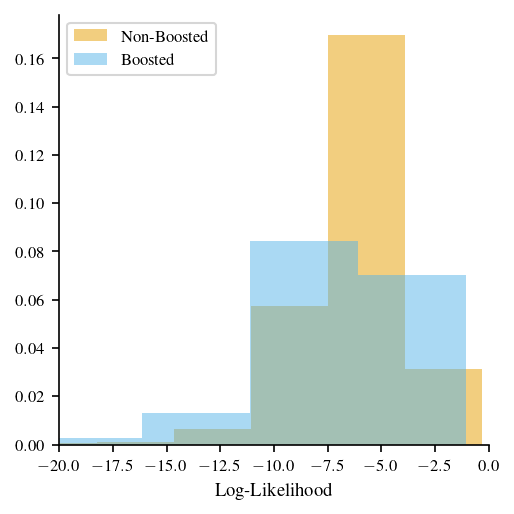

In [36]:
plt.figure(figsize=(COL1, COL1))
for backend, lab in zip([data_nonrel, data_rel], sample_labels):
    chain = backend.get_chain(discard=0)["gb"]  # expected: (steps, temps, walkers, ndim)
    n_steps = chain.shape[0]
    discard = int(0.3 * n_steps)

    logl = backend.get_log_like(discard=discard)
    cold_logl = logl[:, 0].reshape(-1, 1)
    # print(logl.shape, betas.shape)
    plt.hist(cold_logl.flatten(), bins=40, alpha=0.5, label=lab, density=True)
    print("Median log-likelihood for {}: {:.2f}".format(lab, np.mean(cold_logl)))
plt.xlabel("Log-Likelihood")
plt.xlim(-20, 0)
plt.legend()
plt.grid()
plt.tight_layout()

In [37]:
# ── Process and save chains to HDF5 ──────────────────────────────────────────
labels_full = np.array([
    r"$f_0$ [Hz]",
    r"$\dot f_0$ [Hz/s]",
    r"$A$",
    r"$\beta$",
    r"$\lambda$",
    r"$\psi$",
    r"$\iota$",
    r"$\phi_0$",
    r"$\log L$",
])

output_hdf5 = "data/mcmc_chains_processed.h5"

with h5py.File(output_hdf5, "w") as hf:
    # Store injection parameters
    hf.create_dataset("injection_params", data=injection_source_params[:-1])
    hf.create_dataset("param_labels", data=labels_full[:-1].astype('S20'))
    
    # Process both backends
    for backend, lab in zip([data_nonrel, data_rel], ["non_boosted", "boosted"]):
        group = hf.create_group(lab)
        
        chain = backend.get_chain(discard=0)["gb"]  # (steps, temps, walkers, ndim)
        n_steps = chain.shape[0]
        discard = int(0.3 * n_steps)
        
        # Load with burn-in applied
        chain_burned = backend.get_chain(discard=discard)["gb"]
        logl_burned = backend.get_log_like(discard=discard)
        
        # Extract cold chain (temperature index 0)
        cold_samples = chain_burned[:, 0].reshape(-1, chain_burned.shape[-1])
        cold_logl = logl_burned[:, 0].reshape(-1)
        
        # Store raw samples
        group.create_dataset("cold_samples", data=cold_samples)
        group.create_dataset("cold_logl", data=cold_logl)
        
        # Compute and store statistics
        med = np.median(cold_samples, axis=0)
        std = np.std(cold_samples, axis=0)
        bias = med - injection_source_params[:-1]
        bias_sigma = bias / std  # bias in units of posterior std
        
        group.create_dataset("median", data=med)
        group.create_dataset("std", data=std)
        group.create_dataset("bias", data=bias)
        group.create_dataset("bias_sigma", data=bias_sigma)
        
        # Store metadata
        group.attrs["n_samples"] = len(cold_samples)
        group.attrs["n_params"] = cold_samples.shape[1]
        group.attrs["burn_in_steps"] = discard
        group.attrs["label"] = lab
        
        print(f"✓ Processed {lab}: {len(cold_samples)} samples saved")

print(f"\nChains saved to: {output_hdf5}")


✓ Processed non_boosted: 224000 samples saved
✓ Processed boosted: 224000 samples saved

Chains saved to: data/mcmc_chains_processed.h5
